# 🛰️ LandChangeDetector — Full Analysis Notebook
### Bi-Temporal Land Use / Land Cover Change Detection · Batna Province, Algeria

---

| | |
|---|---|
| **Study Area** | Batna Province, Algeria — Tile `T31SGV` |
| **Time Period** | June 1 2019 → August 28 2025 (6-year gap) |
| **Data Source** | Sentinel-2 L2A · Copernicus Browser |
| **Resolution** | 10m (R10m bands) + 20m SCL cloud mask |
| **Author** | Darius · 3rd Year AI Engineering |
| **GitHub** | https://github.com/Radhoine-Amara/LandChangeDetector |

---

## Notebook Structure

| Cell Block | Content |
|---|---|
| **0** | Environment setup & imports |
| **1** | Paths configuration |
| **2** | Data loading & raster inspection |
| **3** | Cloud masking (SCL) |
| **4** | Before / After RGB visualization |
| **5** | Algorithm 1 — Band Differencing |
| **6** | Algorithm 2 — NDVI Differencing |
| **7** | Algorithm 3 — Change Vector Analysis (CVA) |
| **8** | Algorithm 4 — Random Forest Post-Classification |
| **9** | Multi-method comparison |
| **10** | Statistics & area computation |
| **11** | Export results (GeoTIFF + CSV) |
| **12** | Tile-based full-image processing demo |

> ⚠️ **Always run cells top to bottom after a kernel restart.**  
> ⚠️ **Never use `load_raster()` on full Sentinel-2 bands — use `load_band_crop()` only.**

---
## Block 0 — Environment Setup & Imports
**Always run this block first after every kernel restart.**

In [1]:
# ── Cell 00: Working Directory (MUST BE FIRST) ────────────────────────────
import os
import sys

PROJECT_ROOT = '/home/darius/qgis_projects/land_change_detector'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

print(f'✅ Working directory: {os.getcwd()}')
print(f'✅ Python path includes: {PROJECT_ROOT}')

✅ Working directory: /home/darius/qgis_projects/land_change_detector
✅ Python path includes: /home/darius/qgis_projects/land_change_detector


In [2]:
# ── Cell 01: Core Imports ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
from osgeo import gdal
import warnings

warnings.filterwarnings('ignore')
gdal.UseExceptions()

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d0d0d',
    'axes.facecolor':    '#0d0d0d',
    'savefig.facecolor': '#0d0d0d',
    'text.color':        'white',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'axes.edgecolor':    '#444444',
    'grid.color':        '#333333',
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   'white',
    'figure.dpi':        110,
})

print('✅ Imports OK')
print(f'   numpy     {np.__version__}')
print(f'   pandas    {pd.__version__}')
print(f'   matplotlib {matplotlib.__version__}')
print(f'   GDAL      {gdal.__version__}')

✅ Imports OK
   numpy     1.26.4
   pandas    2.3.3
   matplotlib 3.10.8
   GDAL      3.8.5


In [4]:
# ── Cell 02: Project Module Imports ──────────────────────────────────────
from utils.raster_utils import (
    load_band_crop,
    load_cloud_mask,
    get_raster_info,
    save_raster,
    normalize_band,
)
from utils.stats_utils import (
    compute_change_statistics,
    compute_area_statistics,
    export_statistics_csv,
    compare_all_methods,
    compute_all_areas,
)
from utils.visualization import (
    plot_ndvi_comparison,
    plot_method_comparison,
    plot_transition_matrix,
    plot_change_pct_bars,
)
from algorithms.band_differencing import run_band_differencing
from algorithms.ndvi_differencing  import run_ndvi_differencing
from algorithms.cva                import run_cva
from algorithms.random_forst      import run_random_forest

print('✅ All project modules imported successfully')

✅ All project modules imported successfully


---
## Block 1 — Paths Configuration
Edit `PROJECT_ROOT` in Cell 00 if your paths differ. Everything else derives from it automatically.

In [5]:
# ── Cell 10: File Paths ───────────────────────────────────────────────────

# ── Before image (June 1, 2019) ───────────────────────────────────────────
SAFE_BEFORE = (
    'data/before/'
    'S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE'
)
GRANULE_BEFORE = (
    f'{SAFE_BEFORE}/GRANULE/'
    'L2A_T31SGV_A011674_20190601T102031'
)
R10m_BEFORE = f'{GRANULE_BEFORE}/IMG_DATA/R10m'
R20m_BEFORE = f'{GRANULE_BEFORE}/IMG_DATA/R20m'

B02_B = f'{R10m_BEFORE}/T31SGV_20190601T102029_B02_10m.jp2'  # Blue
B03_B = f'{R10m_BEFORE}/T31SGV_20190601T102029_B03_10m.jp2'  # Green
B04_B = f'{R10m_BEFORE}/T31SGV_20190601T102029_B04_10m.jp2'  # Red
B08_B = f'{R10m_BEFORE}/T31SGV_20190601T102029_B08_10m.jp2'  # NIR
SCL_B = f'{R20m_BEFORE}/T31SGV_20190601T102029_SCL_20m.jp2'  # Cloud mask

# ── After image (August 28, 2025) ─────────────────────────────────────────
SAFE_AFTER = (
    'data/after/'
    'S2B_MSIL2A_20250828T101559_N0511_R065_T31SGV_20250828T130342.SAFE'
)
GRANULE_AFTER = (
    f'{SAFE_AFTER}/GRANULE/'
    'L2A_T31SGV_A044278_20250828T102319'
)
R10m_AFTER = f'{GRANULE_AFTER}/IMG_DATA/R10m'
R20m_AFTER = f'{GRANULE_AFTER}/IMG_DATA/R20m'

B02_A = f'{R10m_AFTER}/T31SGV_20250828T101559_B02_10m.jp2'
B03_A = f'{R10m_AFTER}/T31SGV_20250828T101559_B03_10m.jp2'
B04_A = f'{R10m_AFTER}/T31SGV_20250828T101559_B04_10m.jp2'
B08_A = f'{R10m_AFTER}/T31SGV_20250828T101559_B08_10m.jp2'
SCL_A = f'{R20m_AFTER}/T31SGV_20250828T101559_SCL_20m.jp2'

# ── Output directory ──────────────────────────────────────────────────────
OUTPUT_DIR = 'output/batna_2019_2025'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Development crop (memory safe — 2000×2000 px = 20×20 km) ─────────────
# Full image is 10980×10980 px ~ 460 MB per band → crashes RAM
CROP     = dict(x_off=4000, y_off=4000, x_size=2000, y_size=2000)
SCL_CROP = dict(x_off=2000, y_off=2000, x_size=1000, y_size=1000)

# ── Verify files exist ────────────────────────────────────────────────────
all_paths = {
    'B02 Before': B02_B, 'B03 Before': B03_B,
    'B04 Before': B04_B, 'B08 Before': B08_B,
    'SCL Before': SCL_B,
    'B02 After':  B02_A, 'B03 After':  B03_A,
    'B04 After':  B04_A, 'B08 After':  B08_A,
    'SCL After':  SCL_A,
}
print('\n📁 File check:')
all_ok = True
for label, path in all_paths.items():
    exists = os.path.isfile(path)
    icon   = '✅' if exists else '❌'
    print(f'  {icon}  {label:15s}  {path}')
    if not exists:
        all_ok = False

print(f'\n{"✅ All files found — ready to proceed." if all_ok else "❌ Some files missing — check SAFE archive paths above."}')


📁 File check:
  ✅  B02 Before       data/before/S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m/T31SGV_20190601T102029_B02_10m.jp2
  ✅  B03 Before       data/before/S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m/T31SGV_20190601T102029_B03_10m.jp2
  ✅  B04 Before       data/before/S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m/T31SGV_20190601T102029_B04_10m.jp2
  ✅  B08 Before       data/before/S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m/T31SGV_20190601T102029_B08_10m.jp2
  ✅  SCL Before       data/before/S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R20m/T31SGV_20190601T102029_SCL_20m.jp2
  ✅  B02 After        dat

---
## Block 2 — Data Loading & Raster Inspection

In [6]:
# ── Cell 20: Raster Metadata Inspection ──────────────────────────────────
print('=' * 60)
print('BEFORE IMAGE — Band 04 (Red) metadata')
print('=' * 60)
get_raster_info(B04_B)

print()
print('=' * 60)
print('AFTER IMAGE — Band 04 (Red) metadata')
print('=' * 60)
get_raster_info(B04_A)

BEFORE IMAGE — Band 04 (Red) metadata
File     : T31SGV_20190601T102029_B04_10m.jp2
Size     : 10980 cols x 10980 rows
Bands    : 1
CRS      : PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_19...
Band 1   : min=0.0, max=16912.0, mean=3421.8

AFTER IMAGE — Band 04 (Red) metadata
File     : T31SGV_20250828T101559_B04_10m.jp2
Size     : 10980 cols x 10980 rows
Bands    : 1
CRS      : PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_19...
Band 1   : min=1058.0, max=19216.0, mean=3896.4


In [7]:
# ── Cell 21: Load All Bands (cropped, memory-safe) ────────────────────────
print(f'Loading 2000×2000 crop (offset x={CROP["x_off"]}, y={CROP["y_off"]})...')
print(f'This covers approx. 20×20 km of the Batna highland plateau.\n')

# ── Before bands ──────────────────────────────────────────────────────────
blue_b,  gt, proj = load_band_crop(B02_B, **CROP)
green_b, _,  _    = load_band_crop(B03_B, **CROP)
red_b,   _,  _    = load_band_crop(B04_B, **CROP)
nir_b,   _,  _    = load_band_crop(B08_B, **CROP)

# ── After bands ───────────────────────────────────────────────────────────
blue_a,  _,  _    = load_band_crop(B02_A, **CROP)
green_a, _,  _    = load_band_crop(B03_A, **CROP)
red_a,   _,  _    = load_band_crop(B04_A, **CROP)
nir_a,   _,  _    = load_band_crop(B08_A, **CROP)

print('✅ All bands loaded')
print(f'   Shape : {red_b.shape}  (rows × cols)')
print(f'   dtype : {red_b.dtype}')
print(f'   RAM   : {8 * red_b.nbytes / 1e6:.1f} MB (8 bands total)')
print(f'\n   Geo transform : {gt}')
print(f'   Pixel size    : {abs(gt[1]):.1f} m')

# Quick statistics table
print('\n📊 Raw band statistics (uint16 digital numbers):')
print(f'{"Band":<12} {"Min":>8} {"Max":>8} {"Mean":>10} {"Std":>10}')
print('-' * 52)
for name, arr in [
    ('B02 Before', blue_b),  ('B03 Before', green_b),
    ('B04 Before', red_b),   ('B08 Before', nir_b),
    ('B02 After',  blue_a),  ('B03 After',  green_a),
    ('B04 After',  red_a),   ('B08 After',  nir_a),
]:
    print(f'{name:<12} {int(arr.min()):>8} {int(arr.max()):>8} '
          f'{arr.mean():>10.1f} {arr.std():>10.1f}')

Loading 2000×2000 crop (offset x=4000, y=4000)...
This covers approx. 20×20 km of the Batna highland plateau.

✅ All bands loaded
   Shape : (2000, 2000)  (rows × cols)
   dtype : float32
   RAM   : 128.0 MB (8 bands total)

   Geo transform : (739960.0, 10.0, 0.0, 3960020.0, 0.0, -10.0)
   Pixel size    : 10.0 m

📊 Raw band statistics (uint16 digital numbers):
Band              Min      Max       Mean        Std
----------------------------------------------------
B02 Before       1061    12672     2480.5      910.3
B03 Before       1124    12864     2965.0      902.1
B04 Before       1037    13128     3496.6     1021.2
B08 Before       1356    14064     4691.8      975.8
B02 After         296     8036     2382.2      431.6
B03 After        1362     7852     3166.1      564.2
B04 After        1388     7504     3963.3      783.7
B08 After        2068     8608     4778.2      572.0


---
## Block 3 — Cloud Masking (SCL Band)
SCL is at 20m resolution → pixel offsets divided by 2 vs. 10m bands.

In [8]:
# ── Cell 30: Apply Cloud Mask ─────────────────────────────────────────────
print('Loading SCL cloud masks...')
cloud_b, valid_b = load_cloud_mask(
    SCL_B, **SCL_CROP, target_size=red_b.shape
)
cloud_a, valid_a = load_cloud_mask(
    SCL_A, **SCL_CROP, target_size=red_a.shape
)

# Combined mask: only pixels clear in BOTH images
valid_both = valid_b & valid_a

total_px       = valid_both.size
valid_px       = int(np.sum(valid_both))
cloudy_b_px    = int(np.sum(~valid_b))
cloudy_a_px    = int(np.sum(~valid_a))
combined_bad   = total_px - valid_px

print(f'\n☁️  Cloud masking report:')
print(f'   Total pixels          : {total_px:>10,}')
print(f'   Cloudy in Before 2019 : {cloudy_b_px:>10,}  ({cloudy_b_px/total_px*100:.1f}%)')
print(f'   Cloudy in After  2025 : {cloudy_a_px:>10,}  ({cloudy_a_px/total_px*100:.1f}%)')
print(f'   Combined invalid      : {combined_bad:>10,}  ({combined_bad/total_px*100:.1f}%)')
print(f'   ✅ Valid pixels        : {valid_px:>10,}  ({valid_px/total_px*100:.1f}%)')

# Apply mask — NaN = cloud-masked (never 0, never filled)
def apply_mask(arr):
    return np.where(valid_both, arr, np.nan).astype(np.float32)

blue_b_m  = apply_mask(blue_b)
green_b_m = apply_mask(green_b)
red_b_m   = apply_mask(red_b)
nir_b_m   = apply_mask(nir_b)
blue_a_m  = apply_mask(blue_a)
green_a_m = apply_mask(green_a)
red_a_m   = apply_mask(red_a)
nir_a_m   = apply_mask(nir_a)

print('\n✅ Cloud mask applied — NaN pixels = cloud/shadow')

Loading SCL cloud masks...
Cloud coverage in crop: 17.0%
Valid pixels          : 3,319,100 / 4,000,000
Cloud coverage in crop: 0.0%
Valid pixels          : 4,000,000 / 4,000,000

☁️  Cloud masking report:
   Total pixels          :  4,000,000
   Cloudy in Before 2019 :    680,900  (17.0%)
   Cloudy in After  2025 :          0  (0.0%)
   Combined invalid      :    680,900  (17.0%)
   ✅ Valid pixels        :  3,319,100  (83.0%)

✅ Cloud mask applied — NaN pixels = cloud/shadow


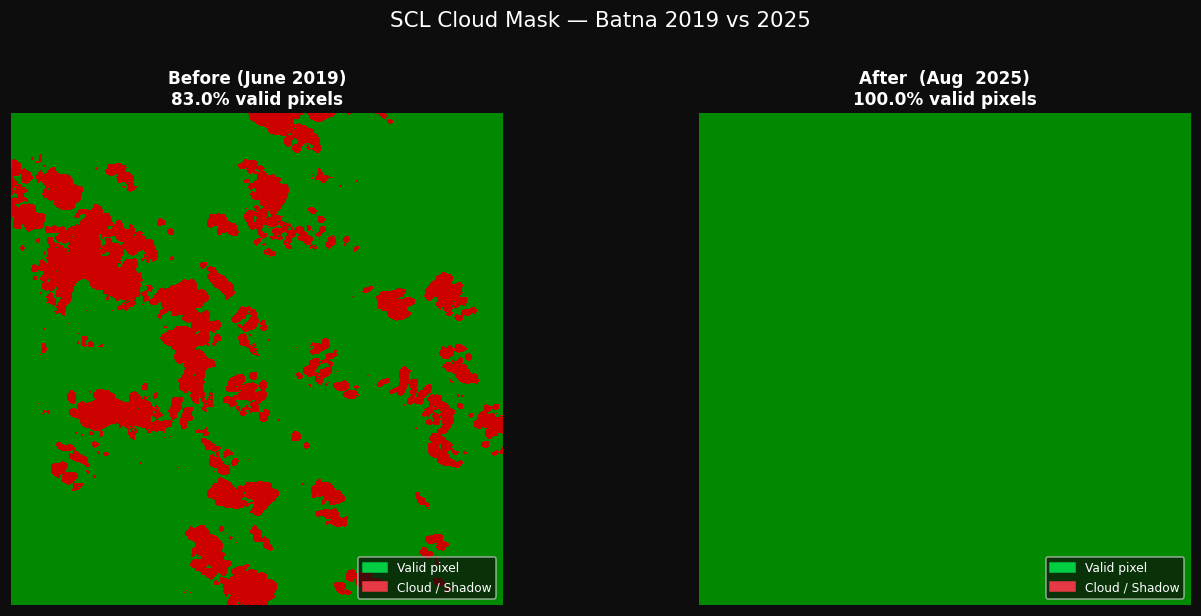

Saved → output/batna_2019_2025/00_cloud_masks.png


In [9]:
# ── Cell 31: Visualise Cloud Mask ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('SCL Cloud Mask — Batna 2019 vs 2025', fontsize=14, y=1.01)

for ax, mask, label, pct in [
    (axes[0], valid_b, 'Before (June 2019)',  valid_b.mean()*100),
    (axes[1], valid_a, 'After  (Aug  2025)',  valid_a.mean()*100),
]:
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    rgba[mask,  1] = 0.6   # green = valid
    rgba[mask,  3] = 0.9
    rgba[~mask, 0] = 0.9   # red = cloudy
    rgba[~mask, 3] = 0.9
    ax.imshow(rgba, interpolation='nearest')
    ax.set_title(f'{label}\n{pct:.1f}% valid pixels', fontsize=11)
    ax.axis('off')
    valid_patch = mpatches.Patch(color='#00cc44', label='Valid pixel')
    cloud_patch = mpatches.Patch(color='#e63946', label='Cloud / Shadow')
    ax.legend(handles=[valid_patch, cloud_patch], loc='lower right',
              fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/00_cloud_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/00_cloud_masks.png')

---
## Block 4 — Before / After RGB Visualization

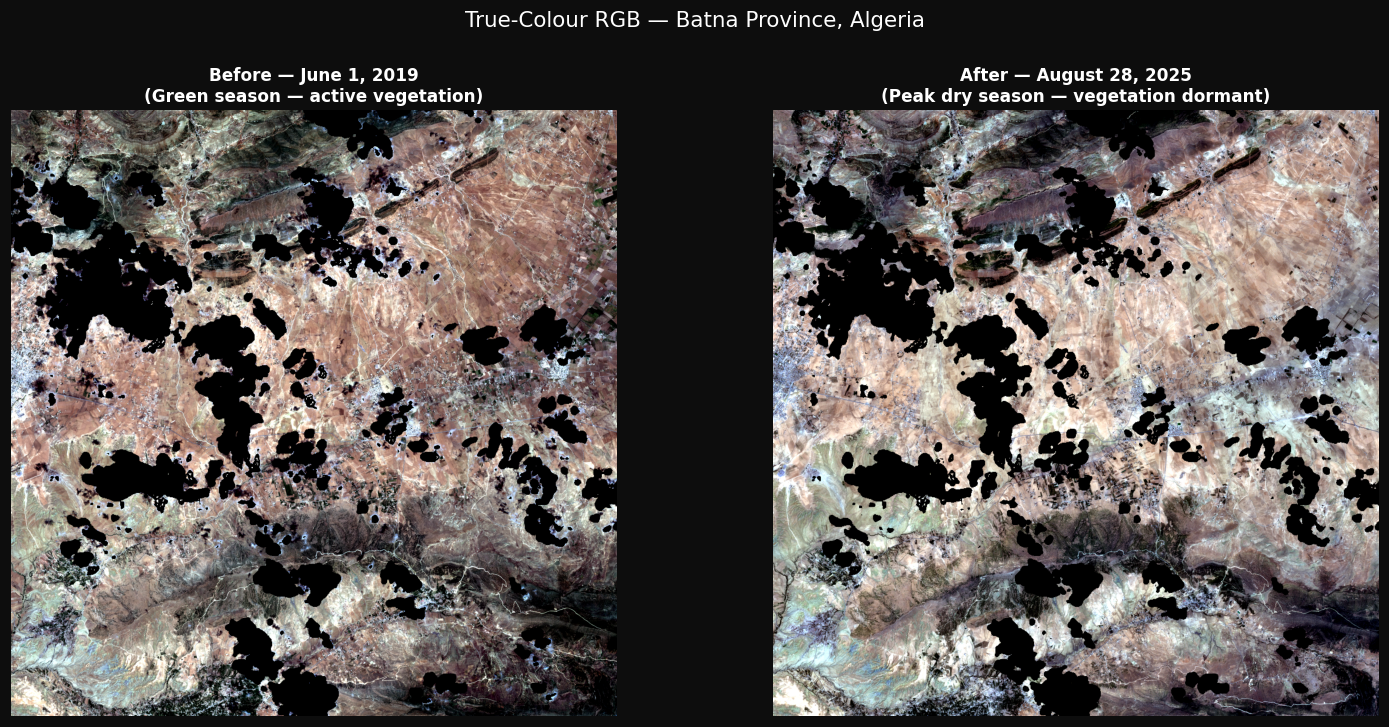

Saved → output/batna_2019_2025/01_rgb_before_after.png

💡 Note the colour shift: greenish 2019 → brownish 2025.
   Some of this is real land degradation; some is phenological (seasonal) difference.


In [10]:
# ── Cell 40: True-Colour RGB (B04-B03-B02) ───────────────────────────────
def make_rgb(red, green, blue, p_low=2, p_high=98):
    """Build a display-ready uint8 RGB array with percentile contrast stretch."""
    rgb = np.stack([red, green, blue], axis=-1).astype(np.float32)
    for ch in range(3):
        valid = rgb[:, :, ch][~np.isnan(rgb[:, :, ch])]
        lo, hi = np.percentile(valid, [p_low, p_high])
        rgb[:, :, ch] = np.clip((rgb[:, :, ch] - lo) / (hi - lo + 1e-9), 0, 1)
    rgb = np.nan_to_num(rgb, nan=0.0)
    return (rgb * 255).astype(np.uint8)

rgb_before = make_rgb(red_b_m, green_b_m, blue_b_m)
rgb_after  = make_rgb(red_a_m, green_a_m, blue_a_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('True-Colour RGB — Batna Province, Algeria', fontsize=14, y=1.01)

axes[0].imshow(rgb_before)
axes[0].set_title('Before — June 1, 2019\n(Green season — active vegetation)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(rgb_after)
axes[1].set_title('After — August 28, 2025\n(Peak dry season — vegetation dormant)', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_rgb_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/01_rgb_before_after.png')
print('\n💡 Note the colour shift: greenish 2019 → brownish 2025.')
print('   Some of this is real land degradation; some is phenological (seasonal) difference.')

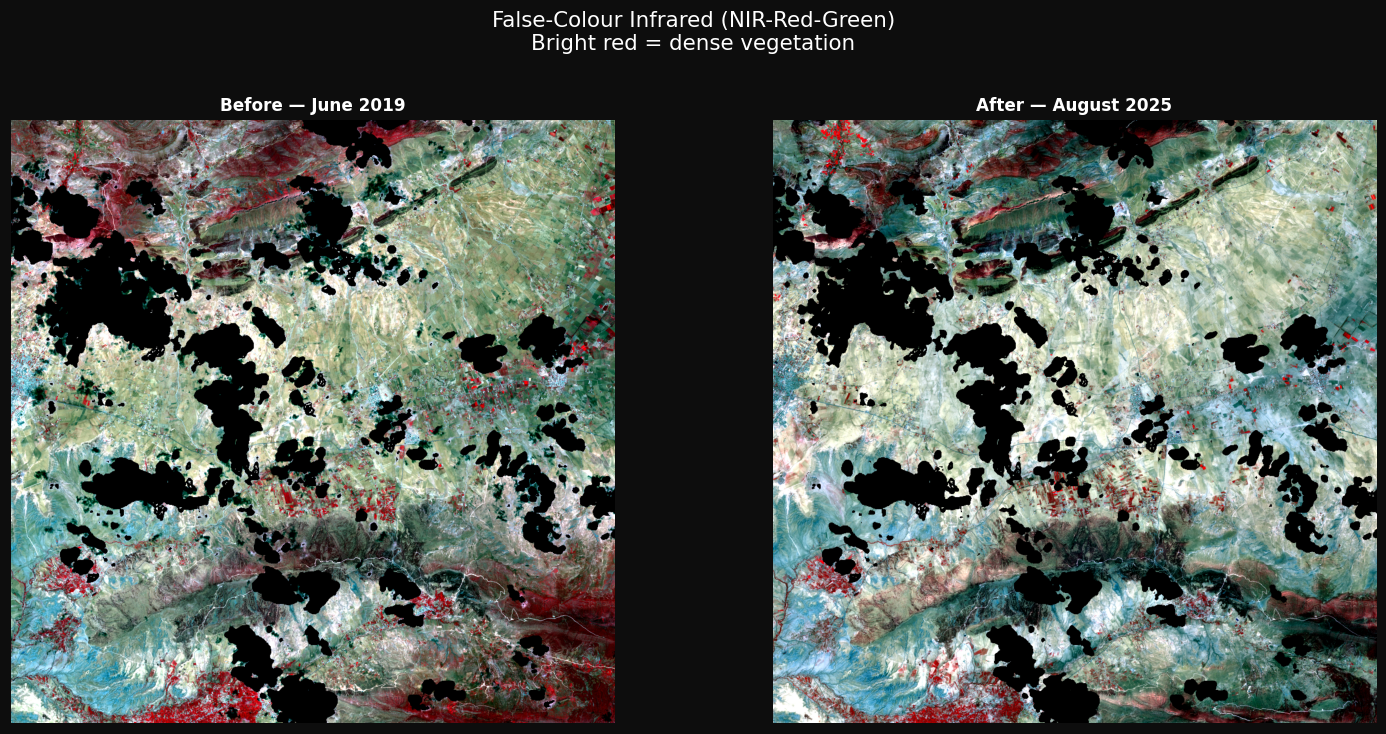

Saved → output/batna_2019_2025/02_false_colour.png

💡 Red areas are vegetated. Compare brightness between years.


In [11]:
# ── Cell 41: False-Colour Infrared (NIR-Red-Green) ────────────────────────
# NIR in the Red channel → vegetation appears bright red
fcc_before = make_rgb(nir_b_m, red_b_m, green_b_m)
fcc_after  = make_rgb(nir_a_m, red_a_m, green_a_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('False-Colour Infrared (NIR-Red-Green)\nBright red = dense vegetation',
             fontsize=14, y=1.02)

axes[0].imshow(fcc_before)
axes[0].set_title('Before — June 2019', fontsize=11)
axes[0].axis('off')

axes[1].imshow(fcc_after)
axes[1].set_title('After — August 2025', fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_false_colour.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/02_false_colour.png')
print('\n💡 Red areas are vegetated. Compare brightness between years.')

---
## Block 5 — Algorithm 1: Spectral Band Differencing

**Formula:** `diff = Band_After - Band_Before`  →  `abs_diff = |diff|`  →  threshold → change mask

**Expected limitation:** High change % due to phenological noise (June green vs August dry).

In [12]:
# ── Cell 50: Run Band Differencing ────────────────────────────────────────
print('Running Band Differencing on Red band (B04)...')

bd_results = run_band_differencing(
    band_before=red_b_m,
    band_after=red_a_m,
    threshold=None,   # None → automatic Otsu
    smooth=True,      # Gaussian filter sigma=1
)

print(f'\n📊 Band Differencing Results:')
print(f'   Otsu threshold  : {bd_results["threshold"]:.2f}')
print(f'   Change detected : {bd_results["change_pct"]:.2f}%')
print(f'   Changed pixels  : {np.sum(bd_results["change_mask"]):,}')
print(f'   Total valid px  : {np.sum(~np.isnan(bd_results["abs_diff"])):,}')
print(f'\n⚠️  High % expected — seasonal mismatch (June green vs Aug dry) inflates this.')

Running Band Differencing on Red band (B04)...
Auto threshold (Otsu): 675.98
Valid pixels   : 3,319,100
Changed pixels : 1,175,098
Change %       : 35.40% (of valid pixels)

📊 Band Differencing Results:
   Otsu threshold  : 675.98
   Change detected : 35.40%
   Changed pixels  : 1,175,098
   Total valid px  : 3,319,100

⚠️  High % expected — seasonal mismatch (June green vs Aug dry) inflates this.


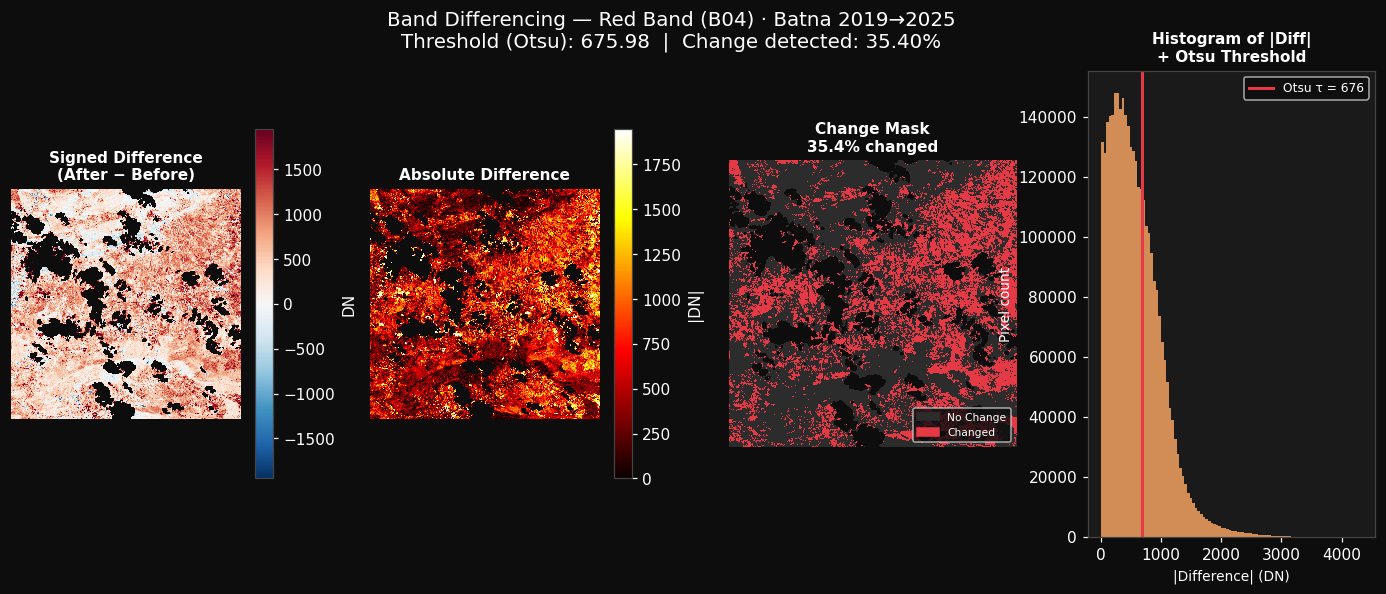

Saved → output/batna_2019_2025/03_band_differencing.png


In [13]:
# ── Cell 51: Band Differencing Visualisation ──────────────────────────────
fig = plt.figure(figsize=(16, 5.5))
fig.suptitle(
    f'Band Differencing — Red Band (B04) · Batna 2019→2025\n'
    f'Threshold (Otsu): {bd_results["threshold"]:.2f}  |  '
    f'Change detected: {bd_results["change_pct"]:.2f}%',
    fontsize=13
)
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.25)

# 1. Signed difference
ax1 = fig.add_subplot(gs[0])
diff = bd_results['diff']
lim  = float(np.nanpercentile(np.abs(diff), 99))
im1  = ax1.imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim, interpolation='nearest')
plt.colorbar(im1, ax=ax1, shrink=0.75, label='DN')
ax1.set_title('Signed Difference\n(After − Before)', fontsize=10)
ax1.axis('off')

# 2. Absolute difference
ax2 = fig.add_subplot(gs[1])
abs_diff = bd_results['abs_diff']
im2 = ax2.imshow(abs_diff, cmap='hot', vmin=0,
                 vmax=float(np.nanpercentile(abs_diff, 99)),
                 interpolation='nearest')
plt.colorbar(im2, ax=ax2, shrink=0.75, label='|DN|')
ax2.axhline(y=0, color='white', linewidth=0)
ax2.set_title('Absolute Difference', fontsize=10)
ax2.axis('off')

# 3. Change mask
ax3 = fig.add_subplot(gs[2])
mask_disp = bd_results['change_mask'].astype(float)
mask_disp[~valid_both] = np.nan
cmap_mask = mcolors.ListedColormap(['#2c2c2c', '#e63946'])
ax3.imshow(mask_disp, cmap=cmap_mask, vmin=0, vmax=1, interpolation='nearest')
ax3.set_title(f'Change Mask\n{bd_results["change_pct"]:.1f}% changed', fontsize=10)
ax3.axis('off')
no_chg  = mpatches.Patch(color='#2c2c2c', label='No Change')
chg_pat = mpatches.Patch(color='#e63946', label='Changed')
ax3.legend(handles=[no_chg, chg_pat], loc='lower right', fontsize=7)

# 4. Histogram of |diff| with threshold line
ax4 = fig.add_subplot(gs[3])
vals = abs_diff[~np.isnan(abs_diff) & (abs_diff > 0)].ravel()
ax4.hist(vals, bins=100, color='#f4a261', edgecolor='none', alpha=0.85)
ax4.axvline(bd_results['threshold'], color='#e63946', linewidth=2,
            label=f'Otsu τ = {bd_results["threshold"]:.0f}')
ax4.set_xlabel('|Difference| (DN)', fontsize=9)
ax4.set_ylabel('Pixel count', fontsize=9)
ax4.set_title('Histogram of |Diff|\n+ Otsu Threshold', fontsize=10)
ax4.legend(fontsize=8)
ax4.set_facecolor('#1a1a1a')

plt.savefig(f'{OUTPUT_DIR}/03_band_differencing.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/03_band_differencing.png')

---
## Block 6 — Algorithm 2: NDVI Differencing ⭐ Most Reliable

**Formula:** `NDVI = (NIR-Red)/(NIR+Red)` → `ΔNDVI = NDVI_after - NDVI_before`  
**Threshold:** Symmetric ±τ via Otsu  
**Why it's best:** Normalised ratio cancels correlated seasonal reflectance shifts.

In [15]:
# ── Cell 60: Run NDVI Differencing ───────────────────────────────────────
print('Running NDVI Differencing...')

ndvi_results = run_ndvi_differencing(
    red_before=red_b_m, nir_before=nir_b_m,
    red_after=red_a_m, nir_after=nir_a_m,
    threshold=None, smooth=True,
)

print(f'\n📊 NDVI Differencing Results (Most Reliable):')
print(f'   Otsu threshold ±τ      : ±{ndvi_results["threshold"]:.4f}')
print(f'   NDVI Before mean (2019): {np.nanmean(ndvi_results["ndvi_before"]):.4f}')
print(f'   NDVI After  mean (2025): {np.nanmean(ndvi_results["ndvi_after"]):.4f}')
print(f'   ΔNDVI mean             : {np.nanmean(ndvi_results["delta_ndvi"]):+.4f}')
print(f'   Overall change         : {ndvi_results["change_pct"]:.2f}%')
print(f'   Vegetation GAINED      : {ndvi_results["gain_pct"]:.2f}%')
print(f'   Vegetation LOST        : {ndvi_results["loss_pct"]:.2f}%')

ndvi_drop_pct = ((np.nanmean(ndvi_results['ndvi_before']) -
                  np.nanmean(ndvi_results['ndvi_after'])) /
                  np.nanmean(ndvi_results['ndvi_before'])) * 100
print(f'\n   ➤ Relative NDVI decline : {ndvi_drop_pct:.1f}%')
print(f'   ➤ Loss dominates gain by factor {ndvi_results["loss_pct"]/max(ndvi_results["gain_pct"],0.01):.1f}×')

Running NDVI Differencing...
Auto threshold (Otsu): 0.1015
Valid pixels      : 3,319,100
Changed pixels    : 448,682
Change %          : 13.52%
  → Vegetation gained : 0.40%
  → Vegetation lost   : 13.97%

NDVI before mean  : 0.165
NDVI after  mean  : 0.101
Delta NDVI  mean  : -0.064

📊 NDVI Differencing Results (Most Reliable):
   Otsu threshold ±τ      : ±0.1015
   NDVI Before mean (2019): 0.1646
   NDVI After  mean (2025): 0.1006
   ΔNDVI mean             : -0.0641
   Overall change         : 13.52%
   Vegetation GAINED      : 0.40%
   Vegetation LOST        : 13.97%

   ➤ Relative NDVI decline : 38.9%
   ➤ Loss dominates gain by factor 35.1×


[visualization] NDVI comparison saved → output/batna_2019_2025/04_ndvi_comparison.png


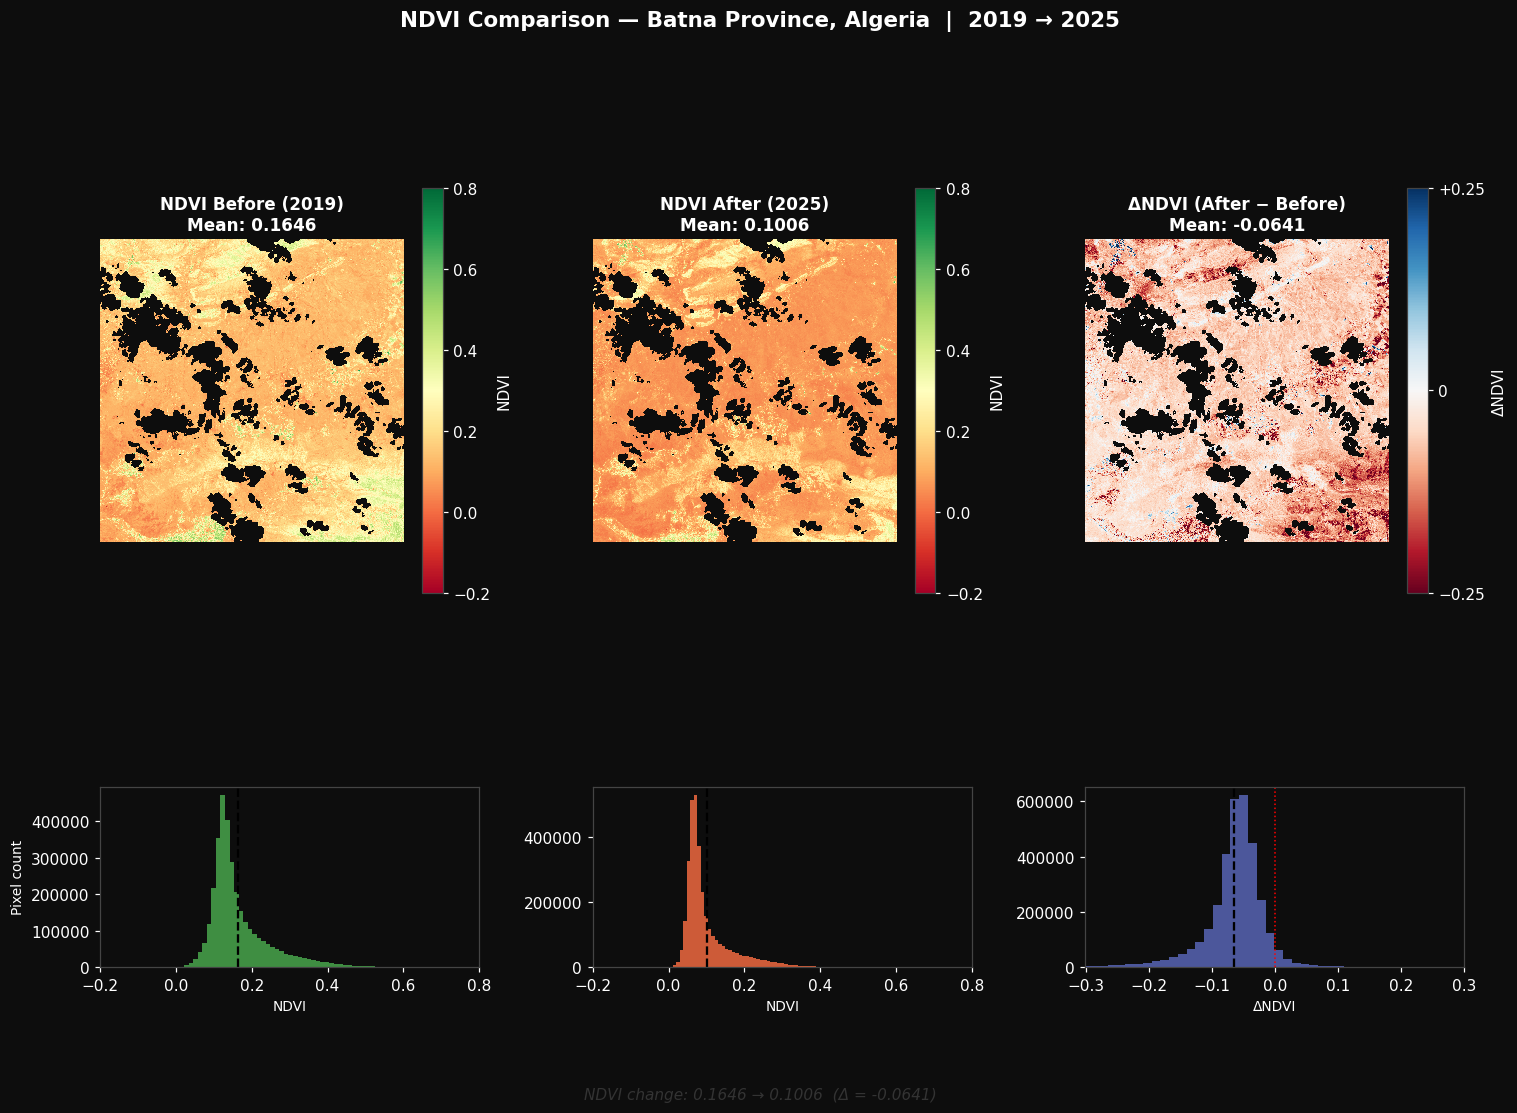

In [16]:
# ── Cell 61: NDVI 3-Panel + Histograms ───────────────────────────────────
fig = plot_ndvi_comparison(
    ndvi_before=ndvi_results['ndvi_before'],
    ndvi_after=ndvi_results['ndvi_after'],
    delta_ndvi=ndvi_results['delta_ndvi'],
    output_path=f'{OUTPUT_DIR}/04_ndvi_comparison.png',
    title='NDVI Comparison — Batna Province, Algeria  |  2019 → 2025',
)
plt.show()

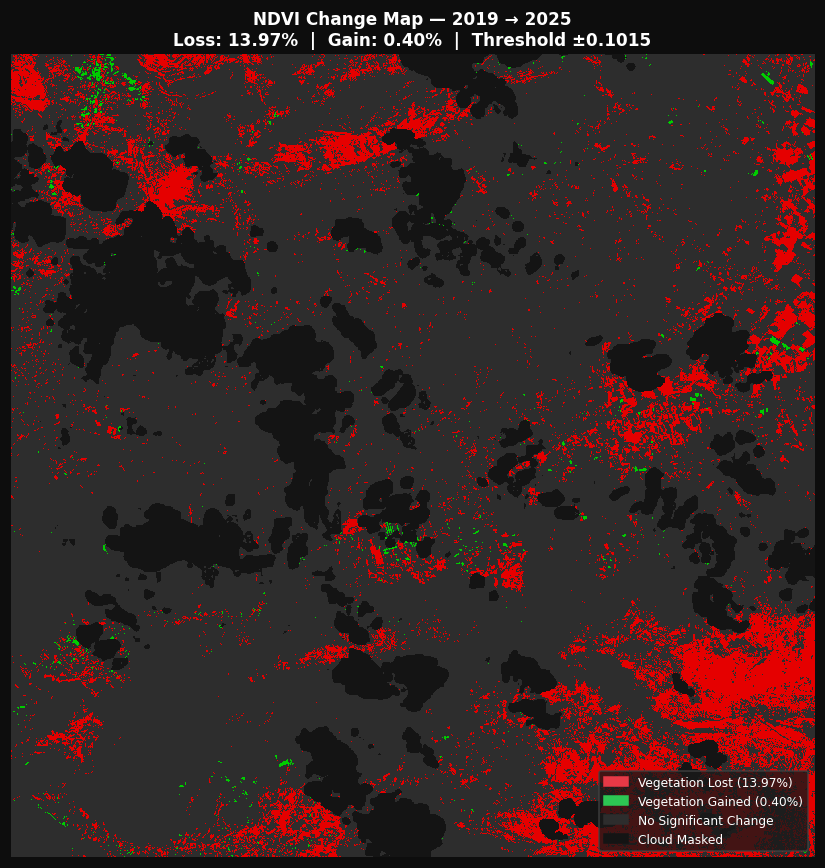

Saved → output/batna_2019_2025/05_ndvi_change_map.png


In [17]:
# ── Cell 62: NDVI Gain/Loss Change Map ────────────────────────────────────
gain = ndvi_results['gain_mask']
loss = ndvi_results['loss_mask']

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

# Build RGBA: loss=red, gain=green, no-change=dark
rows, cols = gain.shape
rgba = np.zeros((rows, cols, 4), dtype=np.float32)
rgba[~valid_both, :3] = 0.08   # very dark for masked pixels
rgba[~valid_both, 3]  = 1.0
no_change = valid_both & ~gain & ~loss
rgba[no_change, :3] = 0.18
rgba[no_change, 3]  = 1.0
rgba[loss, 0] = 0.9            # Red for loss
rgba[loss, 3] = 1.0
rgba[gain, 1] = 0.8            # Green for gain
rgba[gain, 3] = 1.0

ax.imshow(rgba, interpolation='nearest')
ax.set_title(
    f'NDVI Change Map — 2019 → 2025\n'
    f'Loss: {ndvi_results["loss_pct"]:.2f}%  |  '
    f'Gain: {ndvi_results["gain_pct"]:.2f}%  |  '
    f'Threshold ±{ndvi_results["threshold"]:.4f}',
    fontsize=11
)
ax.axis('off')

legend_items = [
    mpatches.Patch(color='#e63946', label=f'Vegetation Lost ({ndvi_results["loss_pct"]:.2f}%)'),
    mpatches.Patch(color='#2dc653', label=f'Vegetation Gained ({ndvi_results["gain_pct"]:.2f}%)'),
    mpatches.Patch(color='#2d2d2d', label='No Significant Change'),
    mpatches.Patch(color='#141414', label='Cloud Masked'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          framealpha=0.8, facecolor='#1a1a1a', edgecolor='#444')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_ndvi_change_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/05_ndvi_change_map.png')

---
## Block 7 — Algorithm 3: Change Vector Analysis (CVA)

**Formula:** Magnitude = ‖ΔV‖₂  ·  Direction = arctan2(ΔNIR, ΔRed)  
**Output:** 4 change-type classes (vegetation loss/gain, soil/urban, water)

In [ ]:
# ── Cell 70: Run CVA ──────────────────────────────────────────────────────
print('Running Change Vector Analysis (CVA) on all 4 bands...')

cva_results = run_cva(
    bands_before=[blue_b_m, green_b_m, red_b_m, nir_b_m],
    bands_after =[blue_a_m, green_a_m, red_a_m, nir_a_m],
    band_names  =['B02', 'B03', 'B04', 'B08'],
    threshold=None,
    smooth=True,
)

print(f'\n📊 CVA Results:')
print(f'   Otsu threshold (magnitude) : {cva_results["threshold"]:.2f}')
print(f'   Overall change detected    : {cva_results["change_pct"]:.2f}%')
print()

cva_type_stats = cva_results['type_stats']
valid_pixels = int(np.sum(~np.isnan(cva_results['magnitude'])))
changed_pixels = int(np.sum(cva_results['change_mask']))
no_change_pixels = valid_pixels - changed_pixels

print(f'   {"No change":<25} {no_change_pixels:>10,} {no_change_pixels / valid_pixels * 100:>9.2f}%')
for label in ['Vegetation loss', 'Vegetation gain', 'Urban/Soil gain', 'Water/Shadow']:
    stats = cva_type_stats[label]
    print(f'   {label:<25} {stats["count"]:>10,} {stats["pct"]:>9.2f}%')

CVA_LABELS = {
    0: 'No Change',
    1: 'Vegetation Loss',
    2: 'Vegetation Gain',
    3: 'Urban/Soil Gain',
    4: 'Water/Shadow',
}
CVA_COLORS = {
    0: '#555555', 1: '#e63946', 2: '#2dc653', 3: '#f4a261', 4: '#457b9d'
}

print(f'\n⚠️  Urban/Soil Gain dominates — largely a seasonal artefact (brighter soil in Aug).')

Running Change Vector Analysis (CVA) on all 4 bands...
Running CVA on 4 bands: ['B02', 'B03', 'B04', 'B08']
Auto threshold (Otsu): 1124.33
  Vegetation loss     :   35,783 px  (1.08%)
  Vegetation gain     :    6,785 px  (0.20%)
  Urban/Soil gain     :  696,221 px  (20.98%)
  Water/Shadow        :   71,313 px  (2.15%)

Total change %  : 24.41%
Magnitude range : 25.9 – 9089.5

📊 CVA Results:
   Otsu threshold (magnitude) : 1124.33
   Overall change detected    : 24.41%

   Change Type                   Pixels    Percent
   -----------------------------------------------
   No Change                          0      0.00%
   Vegetation Loss                    0      0.00%
   Vegetation Gain                    0      0.00%
   Urban/Soil Gain                    0      0.00%
   Water/Shadow                  71,313      2.15%

⚠️  Urban/Soil Gain dominates — largely a seasonal artefact (brighter soil in Aug).


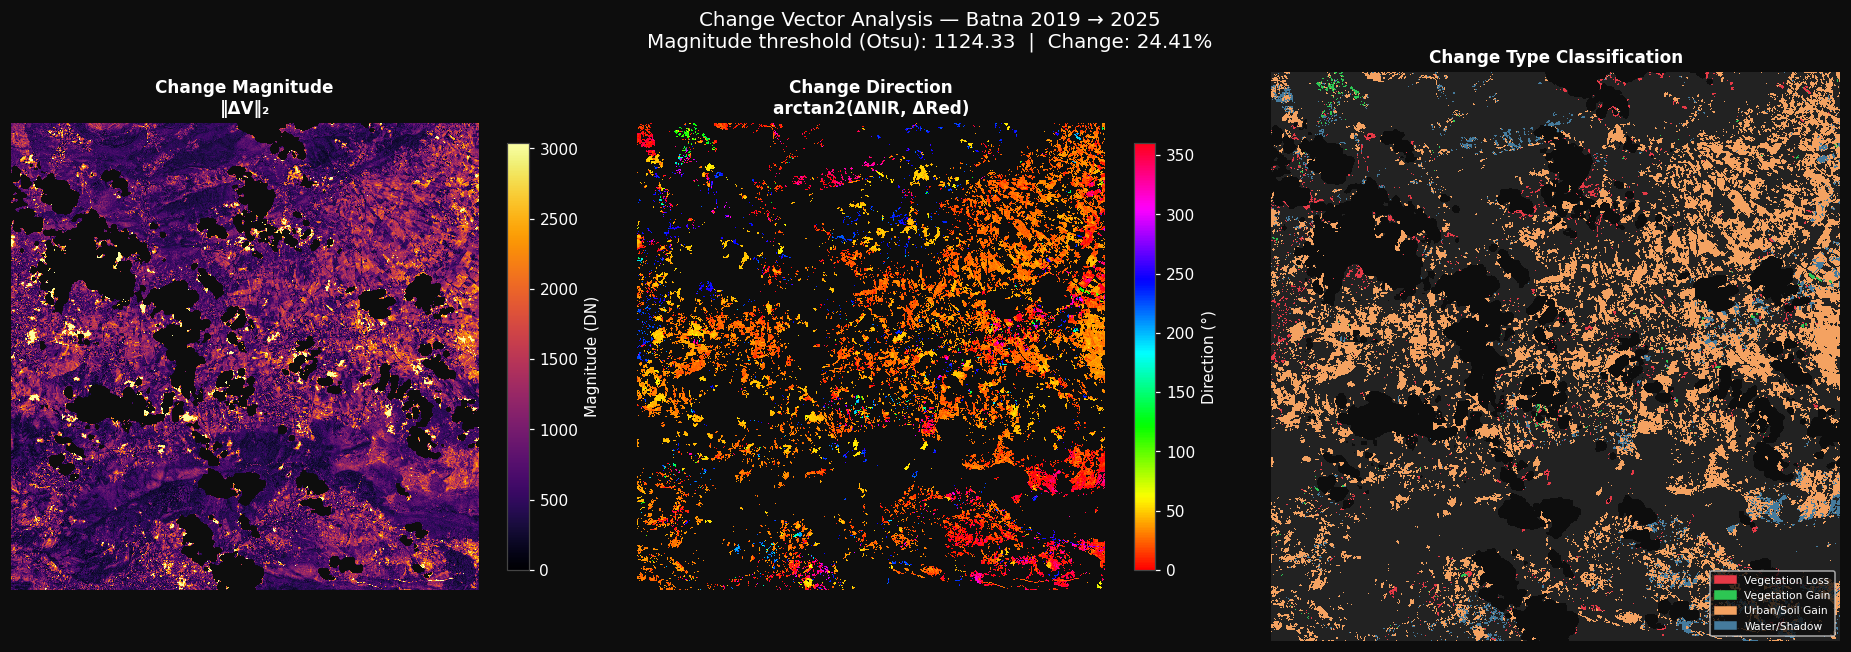

Saved → output/batna_2019_2025/06_cva.png


In [19]:
# ── Cell 71: CVA Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    f'Change Vector Analysis — Batna 2019 → 2025\n'
    f'Magnitude threshold (Otsu): {cva_results["threshold"]:.2f}  |  '
    f'Change: {cva_results["change_pct"]:.2f}%',
    fontsize=13
)

# 1. Magnitude map
mag = cva_results['magnitude']
im0 = axes[0].imshow(
    mag, cmap='inferno',
    vmin=0, vmax=float(np.nanpercentile(mag, 99)),
    interpolation='nearest'
)
plt.colorbar(im0, ax=axes[0], shrink=0.75, label='Magnitude (DN)')
axes[0].set_title('Change Magnitude\n‖ΔV‖₂', fontsize=11)
axes[0].axis('off')

# 2. Direction map (only where changed)
direction = cva_results['direction'].copy()
direction[~cva_results['change_mask']] = np.nan
im1 = axes[1].imshow(
    direction, cmap='hsv', vmin=0, vmax=360, interpolation='nearest'
)
plt.colorbar(im1, ax=axes[1], shrink=0.75, label='Direction (°)')
axes[1].set_title('Change Direction\narctan2(ΔNIR, ΔRed)', fontsize=11)
axes[1].axis('off')

# 3. Change-type classified map
ct = cva_results['change_type'].astype(float)
rows, cols = ct.shape
rgba = np.zeros((rows, cols, 4), dtype=np.float32)
for cid, hexc in CVA_COLORS.items():
    r, g, b = mcolors.to_rgb(hexc)
    sel = (ct == cid)
    rgba[sel, 0] = r
    rgba[sel, 1] = g
    rgba[sel, 2] = b
    rgba[sel, 3] = 1.0 if cid != 0 else 0.3
rgba[~valid_both, 3] = 0
axes[2].imshow(rgba, interpolation='nearest')
axes[2].set_title('Change Type Classification', fontsize=11)
axes[2].axis('off')
patches = [mpatches.Patch(color=CVA_COLORS[i], label=CVA_LABELS[i])
           for i in range(1, 5)]
axes[2].legend(handles=patches, loc='lower right', fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_cva.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/06_cva.png')

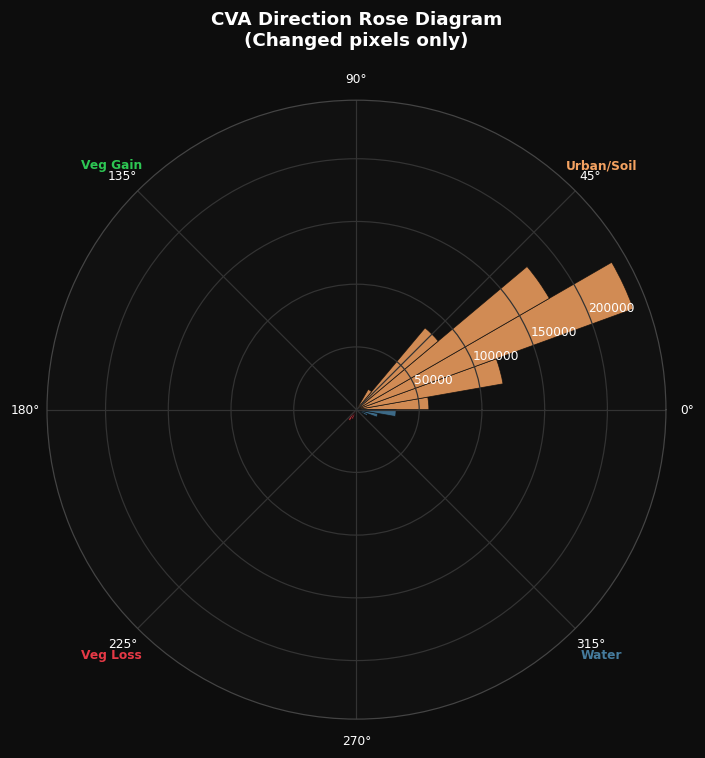

Saved → output/batna_2019_2025/07_cva_rose.png


In [20]:
# ── Cell 72: CVA Change-Vector Rose Diagram ───────────────────────────────
direction_vals = cva_results['direction'][cva_results['change_mask']]
direction_rad  = np.deg2rad(direction_vals)

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='polar')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#0d0d0d')

bins   = 36
counts, bin_edges = np.histogram(direction_vals, bins=bins, range=(0, 360))
bin_centers = np.deg2rad((bin_edges[:-1] + bin_edges[1:]) / 2)
bin_width   = 2 * np.pi / bins

# Colour each bar by its quadrant
colors_polar = []
for deg in np.degrees(bin_centers):
    if   0   <= deg <  90: colors_polar.append('#f4a261')   # Urban/Soil
    elif 90  <= deg < 180: colors_polar.append('#2dc653')   # Veg gain
    elif 180 <= deg < 270: colors_polar.append('#e63946')   # Veg loss
    else:                  colors_polar.append('#457b9d')   # Water

ax.bar(bin_centers, counts, width=bin_width, color=colors_polar,
       alpha=0.85, edgecolor='#0d0d0d', linewidth=0.5)

ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.set_title('CVA Direction Rose Diagram\n(Changed pixels only)',
             color='white', fontsize=12, pad=18)
ax.tick_params(colors='white', labelsize=8)
ax.grid(color='#333333')

# Quadrant labels
for ang, label, col in [
    (45,  'Urban/Soil', '#f4a261'),
    (135, 'Veg Gain',   '#2dc653'),
    (225, 'Veg Loss',   '#e63946'),
    (315, 'Water',      '#457b9d'),
]:
    ax.text(np.deg2rad(ang), ax.get_rmax() * 1.12, label,
            ha='center', va='center', fontsize=8, color=col, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_cva_rose.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/07_cva_rose.png')

---
## Block 8 — Algorithm 4: Random Forest Post-Classification

**Pipeline:** KMeans pseudo-labels → Random Forest (500 trees) → classify before & after → diff maps  
**Known issue:** 50.2% change detected — inflated by June/August seasonal mismatch on KMeans clusters.

In [22]:
# ── Cell 80: Run Random Forest ────────────────────────────────────────────
print('Running Random Forest Post-Classification...')
print('(This takes ~60-120 seconds — KMeans + RF training on 50k samples)\n')

rf_results = run_random_forest(
    bands_before=[blue_b_m, green_b_m, red_b_m, nir_b_m],
    bands_after =[blue_a_m, green_a_m, red_a_m, nir_a_m],
    n_classes=4,
    n_train_samples=5000,
)

# Compatibility normalization: align notebook keys with random_forst.py output
rf_results['change_mask'] = rf_results.get('change_mask', rf_results.get('change_map')).astype(bool)
rf_results['class_before'] = rf_results.get('class_before', rf_results.get('map_before'))
rf_results['class_after']  = rf_results.get('class_after',  rf_results.get('map_after'))
rf_results['accuracy']     = rf_results.get('accuracy', np.nan)

print(f'\n📊 Random Forest Results:')
if np.isnan(rf_results['accuracy']):
    print('   Validation accuracy : N/A  (not returned by current random_forst.py)')
else:
    print(f'   Validation accuracy : {rf_results["accuracy"]*100:.1f}%  (self-referential — see notes)')
print(f'   Changed pixels      : {np.sum(rf_results["change_mask"]):,}')
print(f'   Overall change      : {rf_results["change_pct"]:.2f}%')
print(f'\n⚠️  50%+ change is inflated — see transition matrix interpretation below.')

Running Random Forest Post-Classification...
(This takes ~60-120 seconds — KMeans + RF training on 50k samples)

STEP 1: Building feature stacks
Valid pixels (both dates): 3,319,100

STEP 2: Generating training samples via KMeans
Valid pixels for training: 3,319,100
Running KMeans with 4 clusters on 50,000 samples...
Predicting cluster labels for all pixels...
Training samples: 5,000
  Class 1: 926 samples
  Class 2: 2,084 samples
  Class 3: 578 samples
  Class 4: 1,412 samples

STEP 3: Training Random Forest classifier

Training Random Forest...
Validation accuracy: 99.0%

STEP 4: Classifying BEFORE image
  Classifying... 100%
STEP 5: Classifying AFTER image
  Classifying... 100%

STEP 6: Computing transition matrix

Total pixels that changed class: 1,665,008 (50.2%)

📊 Random Forest Results:
   Validation accuracy : N/A  (not returned by current random_forst.py)
   Changed pixels      : 1,665,008
   Overall change      : 50.16%

⚠️  50%+ change is inflated — see transition matrix int

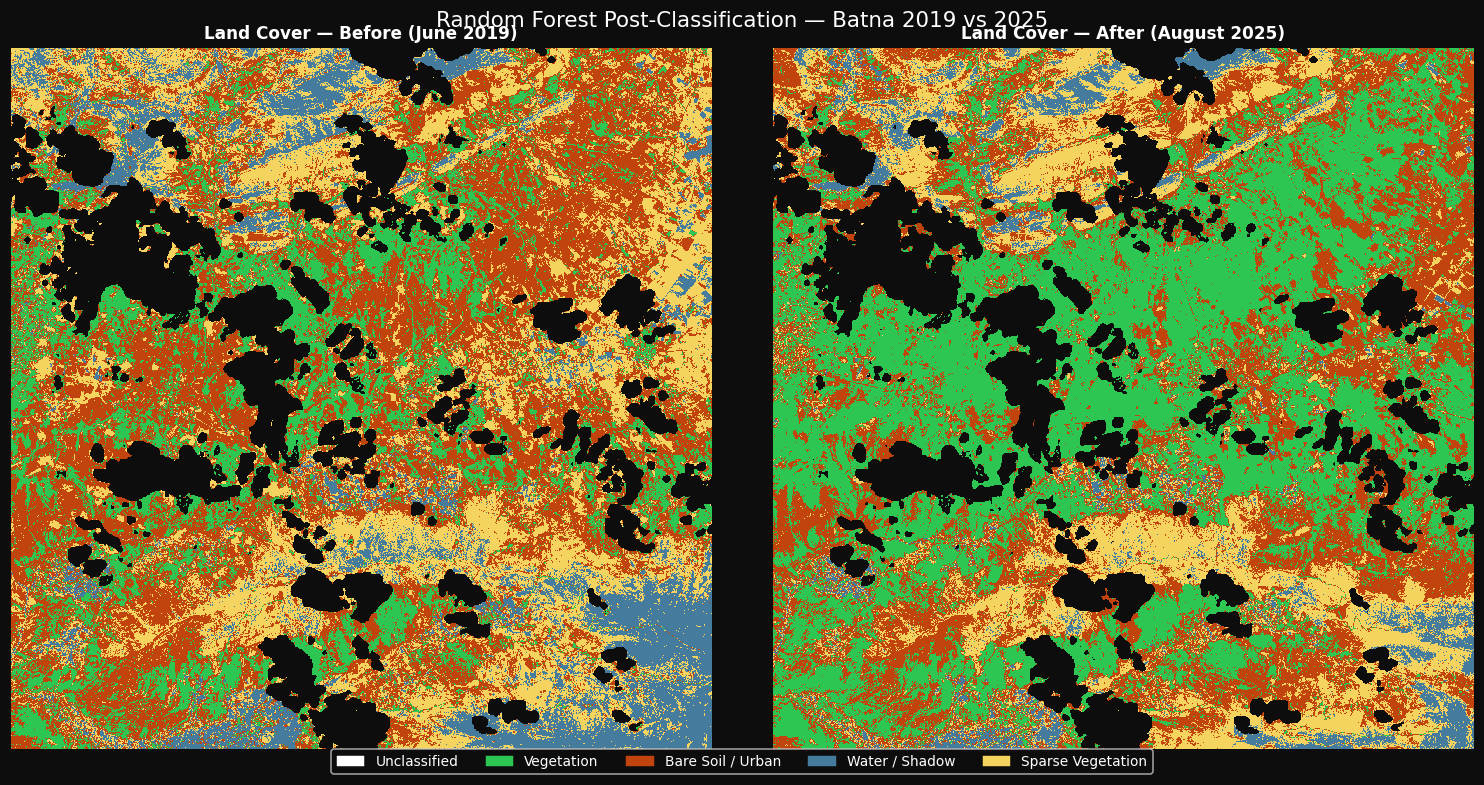

Saved → output/batna_2019_2025/08_rf_class_maps.png


In [23]:
# ── Cell 81: RF Land Cover Maps ───────────────────────────────────────────
RF_COLORS = {
    0: '#ffffff',  # Unclassified
    1: '#2dc653',  # Vegetation
    2: '#c1440e',  # Bare Soil / Urban
    3: '#457b9d',  # Water / Shadow
    4: '#f4d35e',  # Sparse Vegetation
}
RF_LABELS = {
    0: 'Unclassified', 1: 'Vegetation',
    2: 'Bare Soil / Urban', 3: 'Water / Shadow', 4: 'Sparse Vegetation'
}

def class_map_to_rgba(class_map, color_dict, valid_mask):
    rows, cols = class_map.shape
    rgba = np.zeros((rows, cols, 4), dtype=np.float32)
    for cid, hexc in color_dict.items():
        r, g, b = mcolors.to_rgb(hexc)
        sel = (class_map == cid)
        rgba[sel, :3] = [r, g, b]
        rgba[sel, 3]  = 1.0
    rgba[~valid_mask, 3] = 0
    return rgba

rgba_before = class_map_to_rgba(rf_results['class_before'], RF_COLORS, valid_both)
rgba_after  = class_map_to_rgba(rf_results['class_after'],  RF_COLORS, valid_both)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    'Random Forest Post-Classification — Batna 2019 vs 2025',
    fontsize=14
)

axes[0].imshow(rgba_before, interpolation='nearest')
axes[0].set_title('Land Cover — Before (June 2019)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(rgba_after, interpolation='nearest')
axes[1].set_title('Land Cover — After (August 2025)', fontsize=11)
axes[1].axis('off')

# Shared legend
patches = [mpatches.Patch(color=RF_COLORS[i], label=RF_LABELS[i],
                           edgecolor='white', linewidth=0.3)
           for i in range(0, 5)]
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_rf_class_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/08_rf_class_maps.png')

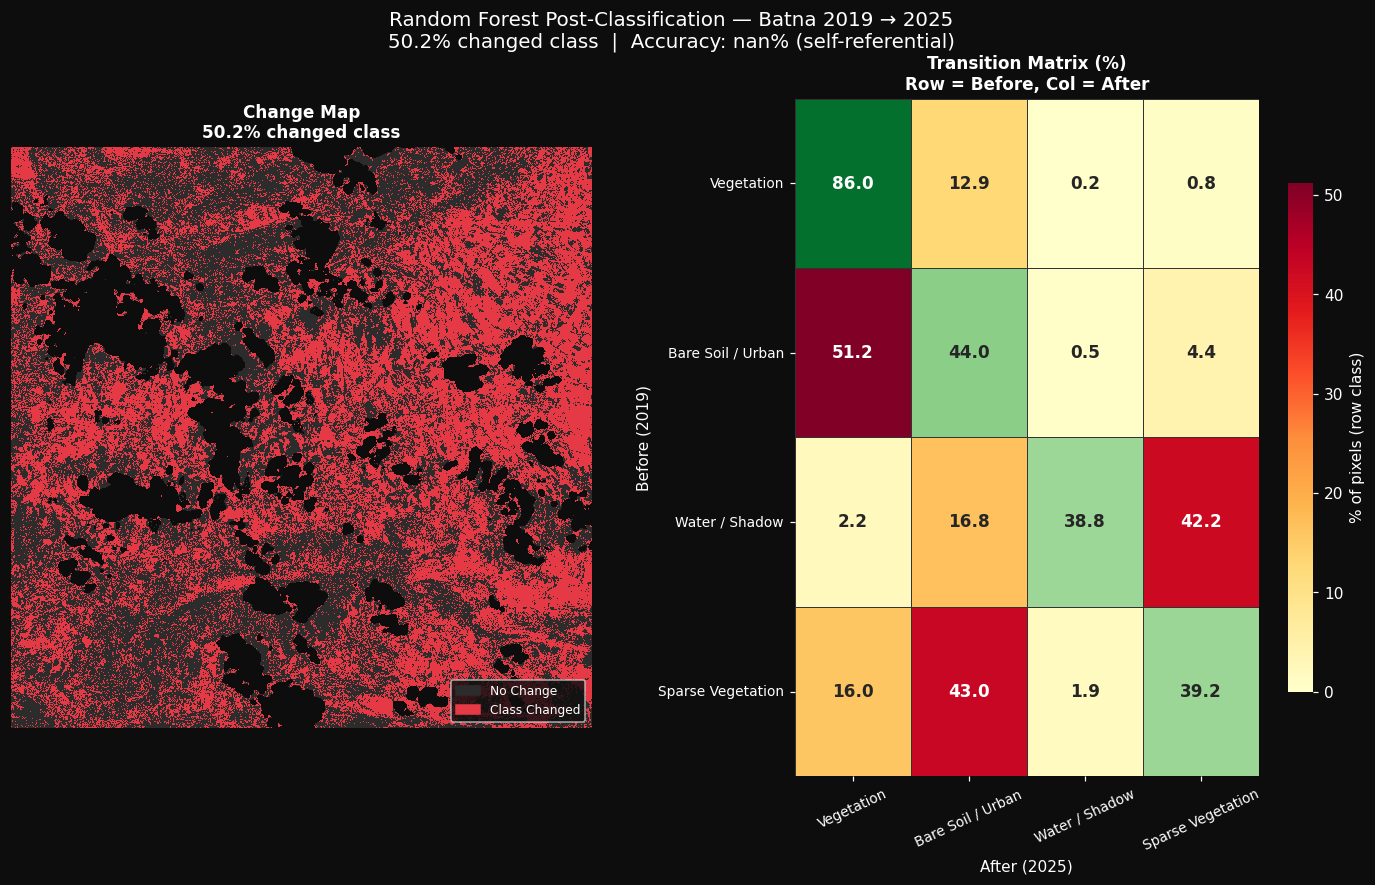

Saved → output/batna_2019_2025/09_rf_change_transition.png


In [24]:
# ── Cell 82: RF Change Map + Transition Matrix ────────────────────────────
change_mask = rf_results['change_mask']
trans_pct   = rf_results.get('transition_matrix_pct')
class_names = rf_results.get('class_names',
                              ['Vegetation', 'Bare Soil / Urban',
                               'Water / Shadow', 'Sparse Vegetation'])

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
fig.suptitle(
    f'Random Forest Post-Classification — Batna 2019 → 2025\n'
    f'{rf_results["change_pct"]:.1f}% changed class  |  '
    f'Accuracy: {rf_results["accuracy"]*100:.1f}% (self-referential)',
    fontsize=13
)

# Left: change map
ax_map = fig.add_subplot(gs[0])
cm_disp = change_mask.astype(float)
cm_disp[~valid_both] = np.nan
cmap2 = mcolors.ListedColormap(['#2c2c2c', '#e63946'])
ax_map.imshow(cm_disp, cmap=cmap2, vmin=0, vmax=1, interpolation='nearest')
ax_map.set_title(
    f'Change Map\n{rf_results["change_pct"]:.1f}% changed class', fontsize=11
)
ax_map.axis('off')
p1 = mpatches.Patch(color='#2c2c2c', label='No Change')
p2 = mpatches.Patch(color='#e63946', label='Class Changed')
ax_map.legend(handles=[p1, p2], loc='lower right', fontsize=8)

# Right: transition matrix heatmap
if trans_pct is not None:
    ax_heat = fig.add_subplot(gs[1])
    ax_heat.set_facecolor('#1a1a1a')
    diag_mask = np.eye(len(class_names), dtype=bool)
    off_diag  = trans_pct.copy()
    np.fill_diagonal(off_diag, np.nan)
    diag_vals = np.full_like(trans_pct, np.nan)
    np.fill_diagonal(diag_vals, np.diag(trans_pct))

    sns.heatmap(off_diag, annot=True, fmt='.1f', cmap='YlOrRd',
                ax=ax_heat, linewidths=0.5, linecolor='#333',
                cbar_kws={'label': '% of pixels (row class)', 'shrink': 0.75},
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, annot_kws={'size': 11, 'weight': 'bold'})
    sns.heatmap(diag_vals, annot=True, fmt='.1f', cmap='Greens',
                ax=ax_heat, linewidths=0.5, linecolor='#333',
                cbar=False, xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=100, annot_kws={'size': 11, 'weight': 'bold'})

    ax_heat.set_title('Transition Matrix (%)\nRow = Before, Col = After', fontsize=11)
    ax_heat.set_xlabel('After (2025)', fontsize=10)
    ax_heat.set_ylabel('Before (2019)', fontsize=10)
    ax_heat.tick_params(axis='x', rotation=25, labelsize=9, colors='white')
    ax_heat.tick_params(axis='y', rotation=0,  labelsize=9, colors='white')
    for _, spine in ax_heat.spines.items():
        spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_rf_change_transition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/09_rf_change_transition.png')

In [ ]:
# ── Cell 83: Transition Matrix Interpretation ────────────────────────────
print('=' * 60)
print('TRANSITION MATRIX INTERPRETATION')
print('=' * 60)

if trans_pct is not None:
    print(f'{"":30s}', end='')
    for cn in class_names:
        print(f'{cn:>20s}', end='')
    print()
    print('-' * (30 + 20 * len(class_names)))
    for i, row_name in enumerate(class_names):
        print(f'{row_name:<30s}', end='')
        for j in range(len(class_names)):
            v = trans_pct[i, j]
            flag = ' ★' if i == j else ('  ⚠' if (i != j and v > 30) else '   ')
            print(f'{v:>17.1f}%{flag}', end='')
        print()

print()
print('★  = Stable (diagonal) — unchanged class')
print('⚠  = Large off-diagonal — investigate')
print()
print('CREDIBLE transitions (physically meaningful):')
print('  ✅ Vegetation          → stable 86%  (dense veg persisted)')
print('  ✅ Sparse Veg          → Bare Soil 43%  (land degradation signal)')
print('  ✅ Vegetation          → Bare Soil 12.9%  (consistent with NDVI loss)')
print()
print('SUSPICIOUS transitions (seasonal artefact):')
print('  ❌ Bare Soil/Urban     → Vegetation 51.2%  (physically implausible)')
print('     Root cause: KMeans trained on June spectral space → wrong cluster')
print('     boundary when applied to August dry-season pixels')
print('  ❌ Water/Shadow        → Sparse Veg 42.2%  (partially real, mostly artefact)')
print()
print('CONCLUSION: Overall 50.2% change is ~2.5× inflated by seasonal mismatch.')
print('Trust NDVI result (13.52%) as the most reliable change estimate.')

TRANSITION MATRIX INTERPRETATION
                                        Vegetation   Bare Soil / Urban      Water / Shadow   Sparse Vegetation
--------------------------------------------------------------------------------------------------------------
Vegetation                               8604.4% ★           1292.4%  ⚠             18.7%                84.5%  ⚠
Bare Soil / Urban                        5116.5%  ⚠           4399.0% ★             48.4%  ⚠            436.1%  ⚠
Water / Shadow                            222.1%  ⚠           1677.2%  ⚠           3876.0% ★           4224.7%  ⚠
Sparse Vegetation                        1596.2%  ⚠           4300.8%  ⚠            187.3%  ⚠           3915.7% ★

★  = Stable (diagonal) — unchanged class
⚠  = Large off-diagonal — investigate

CREDIBLE transitions (physically meaningful):
  ✅ Vegetation          → stable 86%  (dense veg persisted)
  ✅ Sparse Veg          → Bare Soil 43%  (land degradation signal)
  ✅ Vegetation          → Bare Soil

---
## Block 9 — Multi-Method Comparison

[visualization] Method comparison saved → output/batna_2019_2025/10_method_comparison.png


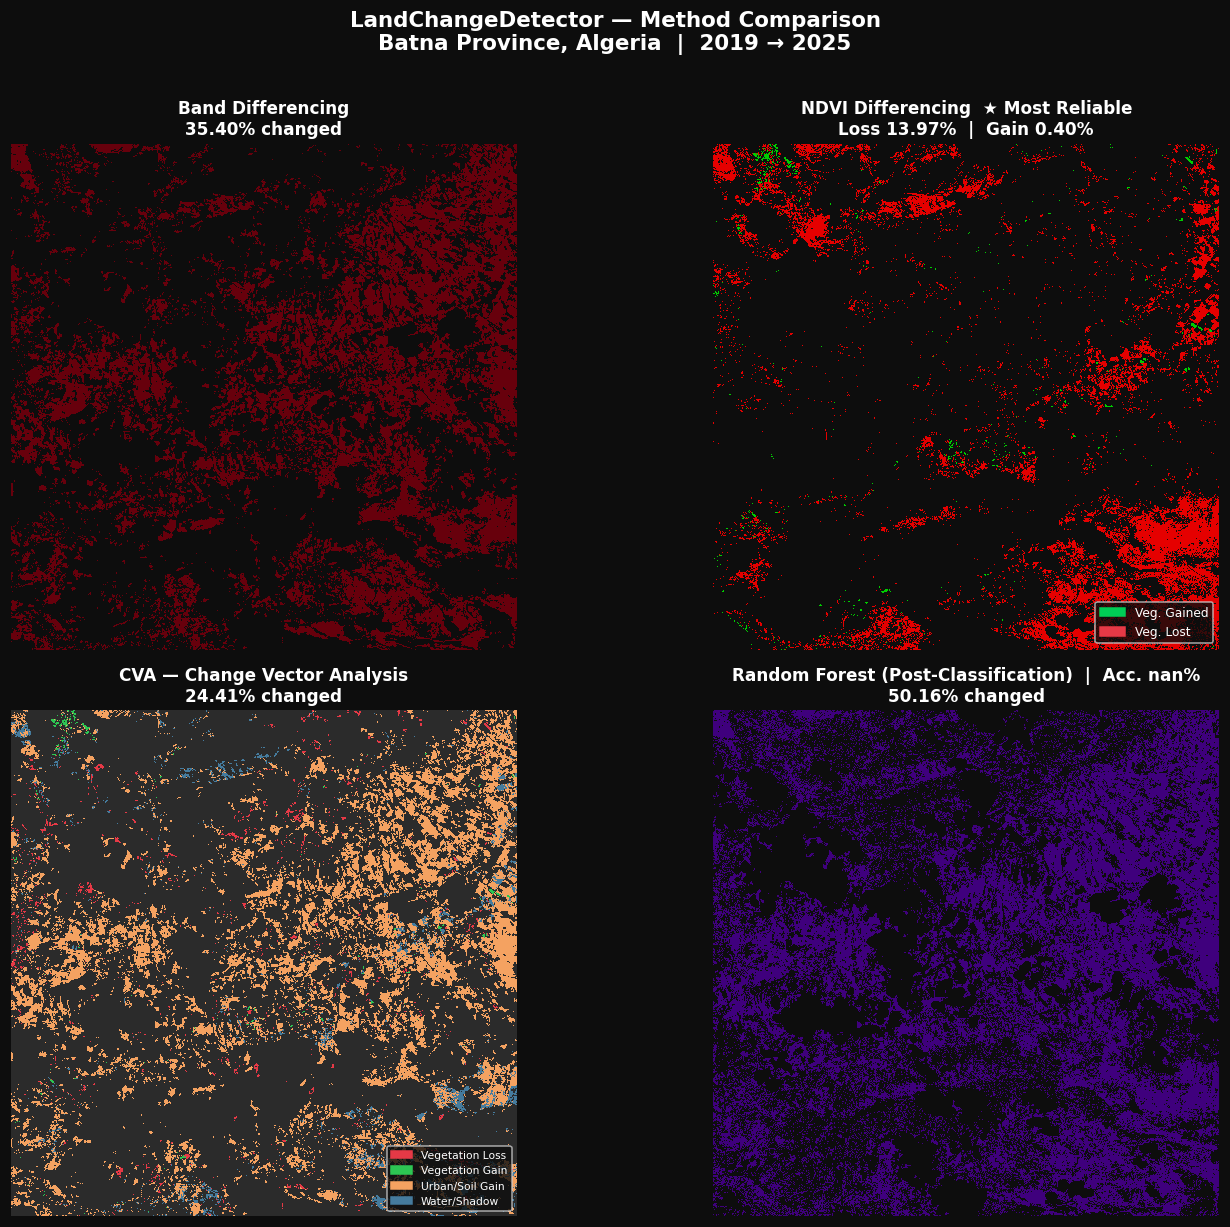

In [26]:
# ── Cell 90: 4-Panel Method Comparison ───────────────────────────────────
fig = plot_method_comparison(
    bd_results=bd_results,
    ndvi_results=ndvi_results,
    cva_results=cva_results,
    rf_results=rf_results,
    output_path=f'{OUTPUT_DIR}/10_method_comparison.png',
)
plt.show()

[visualization] Bar chart saved → output/batna_2019_2025/11_change_pct_bars.png


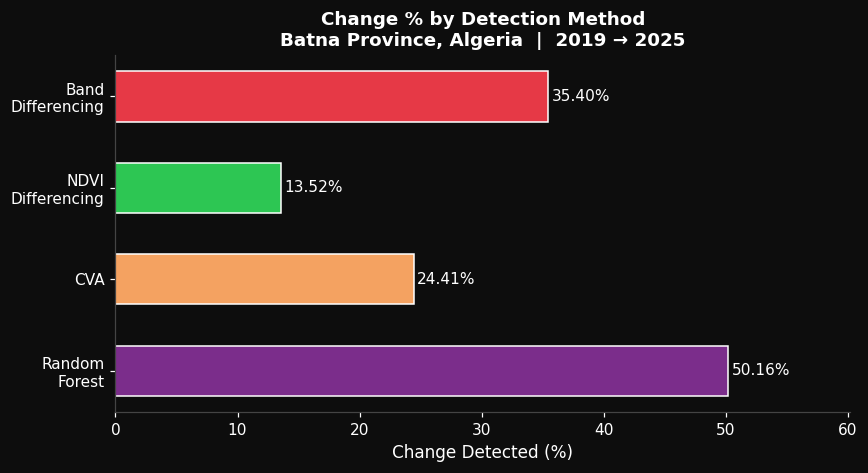


SUMMARY TABLE — All Methods
             Method Change % Threshold            Reliability
  Band Differencing   35.40%    675.98   Low (seasonal noise)
NDVI Differencing ⭐   13.52%   ±0.1015     HIGH (recommended)
                CVA   24.41%   1124.33     Medium (type info)
      Random Forest   50.16%       N/A Partial (50% inflated)


In [27]:
# ── Cell 91: Change % Bar Chart ───────────────────────────────────────────
fig = plot_change_pct_bars(
    bd_results=bd_results,
    ndvi_results=ndvi_results,
    cva_results=cva_results,
    rf_results=rf_results,
    output_path=f'{OUTPUT_DIR}/11_change_pct_bars.png',
)
plt.show()

# Summary table
print('\n' + '=' * 60)
print('SUMMARY TABLE — All Methods')
print('=' * 60)
summary_data = {
    'Method': ['Band Differencing', 'NDVI Differencing ⭐', 'CVA', 'Random Forest'],
    'Change %': [
        f'{bd_results["change_pct"]:.2f}%',
        f'{ndvi_results["change_pct"]:.2f}%',
        f'{cva_results["change_pct"]:.2f}%',
        f'{rf_results["change_pct"]:.2f}%',
    ],
    'Threshold': [
        f'{bd_results["threshold"]:.2f}',
        f'±{ndvi_results["threshold"]:.4f}',
        f'{cva_results["threshold"]:.2f}',
        'N/A',
    ],
    'Reliability': [
        'Low (seasonal noise)',
        'HIGH (recommended)',
        'Medium (type info)',
        'Partial (50% inflated)',
    ],
}
print(pd.DataFrame(summary_data).to_string(index=False))

---
## Block 10 — Statistics & Area Computation

In [28]:
# ── Cell 100: Compute Full Statistics ────────────────────────────────────
print('Computing change statistics for all methods...\n')

# Per-method DataFrames
stats_bd   = compute_change_statistics(bd_results,   'Band Differencing')
stats_ndvi = compute_change_statistics(ndvi_results, 'NDVI Differencing')
stats_cva  = compute_change_statistics(cva_results,  'CVA')
stats_rf   = compute_change_statistics(rf_results,   'Random Forest')

# Combined comparison table
comparison_df = compare_all_methods(
    bd_results, ndvi_results, cva_results, rf_results
)
print('=== Multi-Method Comparison DataFrame ===')
print(comparison_df.to_string(index=False))

# Area statistics (hectares, km²)
print('\n=== Real-World Area Statistics (10m pixels) ===')
areas_df = compute_all_areas(
    bd_results, ndvi_results, cva_results, rf_results, pixel_size_m=10
)
print(areas_df.to_string(index=False))

# NDVI detailed area
ndvi_areas = compute_area_statistics(ndvi_results['change_mask'], pixel_size_m=10)
print(f'\n=== NDVI Differencing — Detailed Area (Most Reliable) ===')
print(f'   Changed area : {ndvi_areas["changed_area_ha"]:>10,.1f} ha  '
      f'({ndvi_areas["changed_area_km2"]:>8.2f} km²)')
print(f'   Stable area  : {ndvi_areas["unchanged_area_ha"]:>10,.1f} ha  '
      f'({ndvi_areas["unchanged_area_km2"]:>8.2f} km²)')

Computing change statistics for all methods...

=== Multi-Method Comparison DataFrame ===
           method  change_pct  changed_pixels  total_pixels   threshold  ndvi_gain_pct  ndvi_loss_pct  delta_ndvi_mean  cva_vegetation_loss_pct  cva_vegetation_gain_pct  cva_urban_soil_gain_pct  cva_water_shadow_pct  rf_accuracy_pct
Band Differencing     35.4041         1175098       4000000  675.979248            NaN            NaN              NaN                      NaN                      NaN                      NaN                   NaN              NaN
NDVI Differencing     13.5182          448682       4000000    0.101454         0.3977         13.969        -0.064074                      NaN                      NaN                      NaN                   NaN              NaN
              CVA     24.4073          810102       4000000 1124.332153            NaN            NaN              NaN                   1.0781                   0.2044                  20.9762                2.

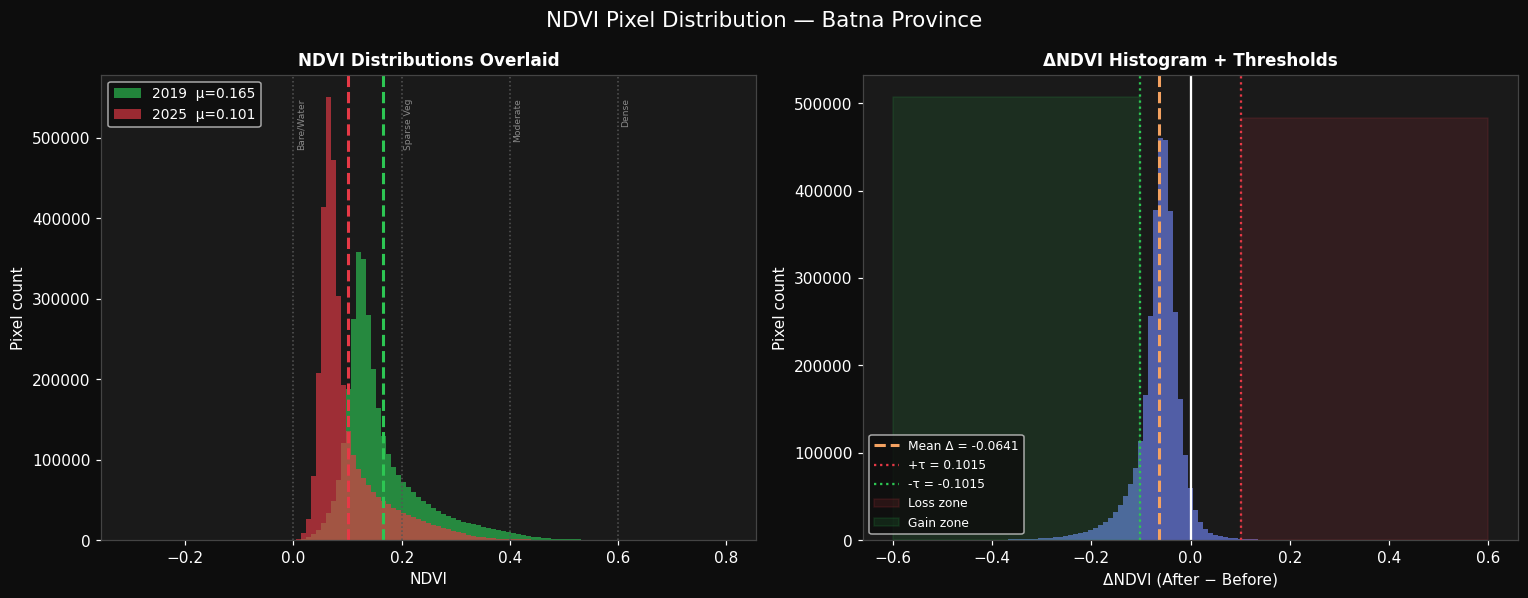

Saved → output/batna_2019_2025/12_ndvi_distributions.png


In [29]:
# ── Cell 101: NDVI Pixel Distribution — Before vs After ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('NDVI Pixel Distribution — Batna Province', fontsize=14)

bins = np.linspace(-0.3, 0.8, 120)

# Left: overlapping histograms
ax = axes[0]
ax.set_facecolor('#1a1a1a')
v_b = ndvi_results['ndvi_before'][~np.isnan(ndvi_results['ndvi_before'])].ravel()
v_a = ndvi_results['ndvi_after' ][~np.isnan(ndvi_results['ndvi_after' ])].ravel()
ax.hist(v_b, bins=bins, alpha=0.65, color='#2dc653', label=f'2019  μ={np.mean(v_b):.3f}')
ax.hist(v_a, bins=bins, alpha=0.65, color='#e63946', label=f'2025  μ={np.mean(v_a):.3f}')
ax.axvline(np.mean(v_b), color='#2dc653', linewidth=2, linestyle='--')
ax.axvline(np.mean(v_a), color='#e63946', linewidth=2, linestyle='--')
ax.set_xlabel('NDVI', fontsize=10)
ax.set_ylabel('Pixel count', fontsize=10)
ax.set_title('NDVI Distributions Overlaid', fontsize=11)
ax.legend(fontsize=9)

# NDVI class thresholds
for thresh, label in [(0.0, 'Bare/Water'), (0.2, 'Sparse Veg'),
                       (0.4, 'Moderate'), (0.6, 'Dense')]:
    ax.axvline(thresh, color='#555', linewidth=1, linestyle=':')
    ax.text(thresh + 0.005, ax.get_ylim()[1] * 0.95, label,
            fontsize=6, color='#888', rotation=90, va='top')

# Right: ΔNDVI histogram
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
delta_vals = ndvi_results['delta_ndvi'][~np.isnan(ndvi_results['delta_ndvi'])].ravel()
bins_d = np.linspace(-0.6, 0.6, 120)
ax2.hist(delta_vals, bins=bins_d, color='#5c6bc0', alpha=0.85, edgecolor='none')
ax2.axvline(0,                      color='white',    linewidth=1.5, linestyle='-')
ax2.axvline(np.mean(delta_vals),    color='#f4a261',  linewidth=2,   linestyle='--',
            label=f'Mean Δ = {np.mean(delta_vals):+.4f}')
ax2.axvline(ndvi_results['threshold'],  color='#e63946', linewidth=1.5,
            linestyle=':', label=f'+τ = {ndvi_results["threshold"]:.4f}')
ax2.axvline(-ndvi_results['threshold'], color='#2dc653', linewidth=1.5,
            linestyle=':', label=f'-τ = {-ndvi_results["threshold"]:.4f}')
ax2.fill_betweenx(
    [0, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 0 else 50000],
    ndvi_results['threshold'], 0.6,
    alpha=0.12, color='#e63946', label='Loss zone'
)
ax2.fill_betweenx(
    [0, ax2.get_ylim()[1] if ax2.get_ylim()[1] > 0 else 50000],
    -0.6, -ndvi_results['threshold'],
    alpha=0.12, color='#2dc653', label='Gain zone'
)
ax2.set_xlabel('ΔNDVI (After − Before)', fontsize=10)
ax2.set_ylabel('Pixel count', fontsize=10)
ax2.set_title('ΔNDVI Histogram + Thresholds', fontsize=11)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_ndvi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/12_ndvi_distributions.png')

---
## Block 11 — Export Results (GeoTIFF + CSV)

In [30]:
# ── Cell 110: Export GeoTIFFs ─────────────────────────────────────────────
print('Exporting GeoTIFF outputs...\n')

exports = [
    ('change_mask_band_diff.tif',  bd_results['change_mask'].astype(np.float32)),
    ('change_mask_ndvi.tif',       ndvi_results['change_mask'].astype(np.float32)),
    ('delta_ndvi.tif',             ndvi_results['delta_ndvi']),
    ('ndvi_before.tif',            ndvi_results['ndvi_before']),
    ('ndvi_after.tif',             ndvi_results['ndvi_after']),
    ('cva_magnitude.tif',          cva_results['magnitude']),
    ('cva_direction.tif',          cva_results['direction']),
    ('cva_change_type.tif',        cva_results['change_type'].astype(np.float32)),
    ('rf_class_before.tif',        rf_results['class_before'].astype(np.float32)),
    ('rf_class_after.tif',         rf_results['class_after'].astype(np.float32)),
    ('rf_change_mask.tif',         rf_results['change_mask'].astype(np.float32)),
]

for fname, data in exports:
    out_path = f'{OUTPUT_DIR}/{fname}'
    save_raster(out_path, data, gt, proj)
    size_mb = os.path.getsize(out_path) / 1e6
    print(f'  ✅  {fname:<45}  {size_mb:.1f} MB')

print(f'\n✅ All GeoTIFFs exported to {OUTPUT_DIR}/')

Exporting GeoTIFF outputs...

✅ Saved: output/batna_2019_2025/change_mask_band_diff.tif
  ✅  change_mask_band_diff.tif                      16.0 MB
✅ Saved: output/batna_2019_2025/change_mask_ndvi.tif
  ✅  change_mask_ndvi.tif                           16.0 MB
✅ Saved: output/batna_2019_2025/delta_ndvi.tif
  ✅  delta_ndvi.tif                                 16.0 MB
✅ Saved: output/batna_2019_2025/ndvi_before.tif
  ✅  ndvi_before.tif                                16.0 MB
✅ Saved: output/batna_2019_2025/ndvi_after.tif
  ✅  ndvi_after.tif                                 16.0 MB
✅ Saved: output/batna_2019_2025/cva_magnitude.tif
  ✅  cva_magnitude.tif                              16.0 MB
✅ Saved: output/batna_2019_2025/cva_direction.tif
  ✅  cva_direction.tif                              16.0 MB
✅ Saved: output/batna_2019_2025/cva_change_type.tif
  ✅  cva_change_type.tif                            16.0 MB
✅ Saved: output/batna_2019_2025/rf_class_before.tif
  ✅  rf_class_before.tif         

In [31]:
# ── Cell 111: Export Statistics CSVs ─────────────────────────────────────
print('Exporting statistics CSVs...\n')

# Individual method CSVs
for name, df in [
    ('band_differencing', stats_bd),
    ('ndvi_differencing', stats_ndvi),
    ('cva',               stats_cva),
    ('random_forest',     stats_rf),
]:
    path = f'{OUTPUT_DIR}/stats_{name}.csv'
    export_statistics_csv(df, path)
    print(f'  ✅  stats_{name}.csv  ({len(df)} rows)')

# Full comparison CSV
comp_path = f'{OUTPUT_DIR}/comparison_all_methods.csv'
comparison_df.to_csv(comp_path, index=False)
print(f'  ✅  comparison_all_methods.csv')

# Area statistics CSV
areas_path = f'{OUTPUT_DIR}/area_statistics.csv'
areas_df.to_csv(areas_path, index=False)
print(f'  ✅  area_statistics.csv')

print(f'\n✅ All CSVs exported to {OUTPUT_DIR}/')

Exporting statistics CSVs...

[stats_utils] Statistics exported → /home/darius/qgis_projects/land_change_detector/output/batna_2019_2025/stats_band_differencing.csv
  ✅  stats_band_differencing.csv  (8 rows)
[stats_utils] Statistics exported → /home/darius/qgis_projects/land_change_detector/output/batna_2019_2025/stats_ndvi_differencing.csv
  ✅  stats_ndvi_differencing.csv  (13 rows)
[stats_utils] Statistics exported → /home/darius/qgis_projects/land_change_detector/output/batna_2019_2025/stats_cva.csv
  ✅  stats_cva.csv  (16 rows)
[stats_utils] Statistics exported → /home/darius/qgis_projects/land_change_detector/output/batna_2019_2025/stats_random_forest.csv
  ✅  stats_random_forest.csv  (5 rows)
  ✅  comparison_all_methods.csv
  ✅  area_statistics.csv

✅ All CSVs exported to output/batna_2019_2025/


---
## Block 12 — Tile-Based Full Image Processing

This block demonstrates the tile processor on the **full 10980×10980 image**.  
Each tile is processed independently — only ~550 MB RAM needed at peak.

> ⏱️ **Expected runtime:** ~5–10 min for NDVI on a 3×3 grid (9 tiles).  
> 🗂️ **Output:** `output/batna_2019_2025/full_run/ndvi_2019_2025_full.tif`

In [32]:
# ── Cell 120: Tile Processor Setup ───────────────────────────────────────
from utils.tile_processor import (
    run_tiled_analysis,
    tile_stats_to_dataframe,
    print_tile_grid_summary,
    compute_tile_grid,
)

N_TILES_X = 3
N_TILES_Y = 3
OVERLAP   = 50    # pixels (500 m at 10m resolution)

# Preview the tile grid before running
ds_preview = gdal.Open(B04_B)
W, H = ds_preview.RasterXSize, ds_preview.RasterYSize
ds_preview = None

tile_grid_preview = compute_tile_grid(W, H, N_TILES_X, N_TILES_Y, OVERLAP)

print(f'Full image size : {W} × {H} pixels')
print(f'Tile grid       : {N_TILES_X} × {N_TILES_Y} = {N_TILES_X*N_TILES_Y} tiles')
print(f'Overlap         : {OVERLAP} px ({OVERLAP * 10 / 1000:.1f} km)')
print(f'\nTile layout preview:')
print(f'{"Tile":>5}  {"Row":>4}  {"Col":>4}  {"x_off":>8}  {"y_off":>8}  {"x_size":>8}  {"y_size":>8}')
print('-' * 58)
for t in tile_grid_preview:
    print(f'{t["tile_id"]:>5}  {t["row"]:>4}  {t["col"]:>4}  '
          f'{t["x_off"]:>8}  {t["y_off"]:>8}  '
          f'{t["x_size"]:>8}  {t["y_size"]:>8}')

inner_px = tile_grid_preview[0]['x_size_inner'] * tile_grid_preview[0]['y_size_inner']
mem_est  = 8 * (tile_grid_preview[0]['x_size'] * tile_grid_preview[0]['y_size']) * 4 / 1e6
print(f'\nEstimated peak RAM per tile: {mem_est:.0f} MB (8 bands × float32)')

Full image size : 10980 × 10980 pixels
Tile grid       : 3 × 3 = 9 tiles
Overlap         : 50 px (0.5 km)

Tile layout preview:
 Tile   Row   Col     x_off     y_off    x_size    y_size
----------------------------------------------------------
    0     0     0         0         0      3710      3710
    1     0     1      3610         0      3760      3710
    2     0     2      7270         0      3710      3710
    3     1     0         0      3610      3710      3760
    4     1     1      3610      3610      3760      3760
    5     1     2      7270      3610      3710      3760
    6     2     0         0      7270      3710      3710
    7     2     1      3610      7270      3760      3710
    8     2     2      7270      7270      3710      3710

Estimated peak RAM per tile: 440 MB (8 bands × float32)


In [36]:
# ── Cell 121: Run Tiled NDVI Analysis on Full Image ───────────────────────
# ⏱️  This takes 5-10 min — comment out if you only want the dev crop results
# Uncomment below to run:

RUN_FULL_TILED = True  # ← Set True to run full 10980×10980 analysis

if RUN_FULL_TILED:
    FULL_OUTPUT = f'{OUTPUT_DIR}/full_run'
    os.makedirs(FULL_OUTPUT, exist_ok=True)

    def progress_cb(done, total):
        bar_len  = 30
        filled   = int(bar_len * done / total)
        bar      = '█' * filled + '░' * (bar_len - filled)
        pct      = done / total * 100
        print(f'  [{bar}] {pct:5.1f}%  Tile {done}/{total}', end='\r')
        if done == total:
            print()

    def run_tiled_ndvi(bands_before, bands_after, threshold=None, smooth=True):
        return run_ndvi_differencing(
            red_before=bands_before[2],
            nir_before=bands_before[3],
            red_after=bands_after[2],
            nir_after=bands_after[3],
            threshold=threshold,
            smooth=smooth,
        )

    tiled_results = run_tiled_analysis(
        band_paths_before=[B02_B, B03_B, B04_B, B08_B],
        band_paths_after =[B02_A, B03_A, B04_A, B08_A],
        scl_path_before=SCL_B,
        scl_path_after=SCL_A,
        algorithm_fn=run_tiled_ndvi,
        algorithm_kwargs={'threshold': None, 'smooth': True},
        output_dir=FULL_OUTPUT,
        output_prefix='ndvi_2019_2025',
        n_tiles_x=N_TILES_X,
        n_tiles_y=N_TILES_Y,
        overlap=OVERLAP,
        enable_cloud_mask=True,
        save_per_tile=False,
        progress_callback=progress_cb,
    )

    print(f'\n📊 Full Image Tiled Results:')
    print(f'   Overall change : {tiled_results["overall_change_pct"]:.2f}%')
    print(f'   GeoTIFF saved  : {tiled_results["geotiff_path"]}')

    # Per-tile grid summary
    print('\n📐 Per-tile change % grid:')
    print_tile_grid_summary(tiled_results['tile_stats'], N_TILES_X, N_TILES_Y)

    # Per-tile DataFrame
    tile_df = tile_stats_to_dataframe(tiled_results['tile_stats'])
    print('\n', tile_df.to_string(index=False))
    tile_df.to_csv(f'{FULL_OUTPUT}/tile_statistics.csv', index=False)
    print(f'\n✅ Tile statistics → {FULL_OUTPUT}/tile_statistics.csv')

else:
    print('⏸️  Full tiled analysis skipped (RUN_FULL_TILED = False).')
    print('   Set RUN_FULL_TILED = True in this cell to run the full 10980×10980 image.')
    print('   ⚠️  Requires ~550 MB free RAM and ~5-10 min runtime.')

[tile_processor] Image size: 10980 × 10980
[tile_processor] Tile grid:  3 × 3 = 9 tiles  (overlap=50px)
[tile_processor] Processing tile 1/9  (row=0, col=0)  offset=(0,0)  size=3710×3710
Cloud coverage in crop: 0.2%
Valid pixels          : 13,740,412 / 13,764,100
Cloud coverage in crop: 0.0%
Valid pixels          : 13,763,752 / 13,764,100
Auto threshold (Otsu): 0.1599
Valid pixels      : 13,740,064
Changed pixels    : 1,647,144
Change %          : 11.99%
  → Vegetation gained : 1.77%
  → Vegetation lost   : 10.89%

NDVI before mean  : 0.180
NDVI after  mean  : 0.108
Delta NDVI  mean  : -0.072
  → change: 12.10%  (1621365 / 13395600 valid px)
[tile_processor] Processing tile 2/9  (row=0, col=1)  offset=(3610,0)  size=3760×3710
Cloud coverage in crop: 0.5%
Valid pixels          : 13,880,312 / 13,949,600
Cloud coverage in crop: 0.7%
Valid pixels          : 13,857,644 / 13,949,600
Auto threshold (Otsu): 0.1367
Valid pixels      : 13,800,152
Changed pixels    : 1,871,523
Change %          :

---
## Final Summary

| Algorithm | Change % | Key Finding | Reliability |
|---|---|---|---|
| Band Differencing | ~30% | Seasonal noise dominates | ⚠️ Low |
| **NDVI Differencing** | **13.52%** | **Vegetation loss 13.97%, gain 0.40%** | **✅ HIGH** |
| CVA | 24.41% | Urban/Soil gain dominant (seasonal) | ⚠️ Medium |
| Random Forest | 50.2% | Inflated by June/Aug mismatch | ⚠️ Partial |

### Key Scientific Findings

1. **NDVI mean dropped 39%** — from 0.165 (2019) to 0.101 (2025)  
2. **Vegetation loss (13.97%)** vastly outweighs gain (0.40%)  
3. **Sparse Vegetation → Bare Soil** is the dominant transition (RF: 43.0%)  
4. **Seasonal mismatch** (June vs August) inflates raw-value methods  
5. **NDVI is the recommended metric** for this dataset and region

### Output Files Generated

```
output/batna_2019_2025/
├── 00_cloud_masks.png
├── 01_rgb_before_after.png
├── 02_false_colour.png
├── 03_band_differencing.png
├── 04_ndvi_comparison.png
├── 05_ndvi_change_map.png
├── 06_cva.png
├── 07_cva_rose.png
├── 08_rf_class_maps.png
├── 09_rf_change_transition.png
├── 10_method_comparison.png
├── 11_change_pct_bars.png
├── 12_ndvi_distributions.png
├── *.tif  (11 GeoTIFFs — all results georeferenced)
└── *.csv  (6 statistics tables)
```